# PHẦN 1: GIỚI THIỆU DỮ LIỆU

## 1.1. Lý do chọn đề tài
Hiện nay, nhu cầu tìm kiếm phòng trọ của sinh viên tại Thành phố Hồ Chí Minh rất cao, nhưng thông tin thị trường còn phân tán, khó so sánh. Việc thu thập, làm sạch và phân tích dữ liệu giúp hiểu rõ hơn về giá thuê, vị trí, diện tích và các yếu tố ảnh hưởng, đồng thời hỗ trợ sinh viên tìm phòng phù hợp và chủ trọ định giá hợp lý.

## 1.2. Nguồn dữ liệu
* Website thu thập: https://phongtro123.com/
* Thời gian thu thập: Năm 2025
* Số lượng bản ghi: Khoảng 7.000 tin đăng
* Phạm vi địa lý: Các quận trung tâm và ngoại thành TP.HCM (Quận 1, Gò Vấp, Bình Thạnh, Thủ Đức, Quận 9, Quận 12, v.v.)

## 1.3. Mục tiêu nghiên cứu
* Phân tích đặc điểm thị trường cho thuê phòng trọ tại TP.HCM.
* Khám phá mối quan hệ giữa giá thuê, diện tích và vị trí địa lý.
* Xây dựng mô hình phân cụm và dự đoán giá phòng trọ dựa trên các đặc tính cơ bản.

## 1.4. Câu hỏi nghiên cứu (Tổng hợp)
1. Thị trường phòng trọ TP.HCM được phân khúc như thế nào dựa trên giá cả, diện tích và vị trí địa lý?
  	 Sử dụng: Phân cụm K-Means + DBSCAN
2. Yếu tố nào ảnh hưởng mạnh nhất đến giá thuê phòng trọ: diện tích hay vị trí quận?
  	 Sử dụng: Correlation analysis + Regression
3. Có thể dự đoán chính xác phân khúc giá của phòng trọ dựa trên các đặc tính cơ bản không?
   	Sử dụng: Classification models (Random Forest, XGBoost)
4. Sự khác biệt về giá thuê và đặc điểm phòng trọ giữa các quận trung tâm và ngoại thành như thế nào?
    Sử dụng: Comparative analysis + Visualization
5. Phân khúc phòng trọ nào mang lại giá trị tốt nhất cho người thuê về tỷ lệ giá/diện tích/vị trí?
    Sử dụng: Value analysis + Cluster interpretation

## 1.5. Cấu trúc tập dữ liệu

| Tên trường      | Mô tả                      |
| --------------- | -------------------------- |
| `url`           | Liên kết gốc của tin đăng  |
| `title`         | Tiêu đề bài viết           |
| `price_raw`     | Giá thuê thô (chuỗi ký tự) |
| `area_raw`      | Diện tích thô              |
| `address`       | Địa chỉ chi tiết           |
| `post_code`     | Mã bài đăng                |
| `description`   | Mô tả nội dung             |
| `contact_phone` | Số điện thoại liên hệ      |
| `images`        | Đường dẫn hình ảnh         |


# PHẦN 2: PHÂN TÍCH MÔ TẢ

## 2.1. Nhập thư viện

In [1]:
# pip install aiohttp async-timeout tqdm pandas beautifulsoup4 lxml requests
# !pip install streamlit -q
!pip install shap statsmodels

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from urllib.parse import urlparse, unquote

from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import RobustScaler  # Cho outliers
import plotly.express as px  # Để merge với map
from statsmodels.tsa.arima.model import ARIMA  # Cho forecasting
import shap  # Cho explainability

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


## 2.2. Đọc dữ liệu

In [3]:
df = pd.read_csv("/kaggle/input/crawl-house-hcm-vietnam/results_hcm.csv")
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images
0,https://phongtro123.com/tinh-thanh/ho-chi-minh,"Cho Thuê Phòng Trọ Hồ Chí Minh, Giá Rẻ, Tiện N...",Hôm nay,13 K,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Chủ sở hữu Nhà Trọ Ngõ Sen chia sẻ rằng: ""Trướ...",974188183.0,['https://pt123.cdn.static123.com/images/thumb...
1,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 1, Giá Rẻ, Tiện Nghi, ...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Bên cạnh đó, hệ thống giao thông quận 1 rất hi...",917686101.0,['https://pt123.cdn.static123.com/images/thumb...
2,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 12, Giá Rẻ, Tiện Nghi,...",Hôm nay,3.5 triệu/tháng,35 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo dữ liệu cập nhật chính xác từ https://pho...,914579786.0,['https://pt123.cdn.static123.com/images/thumb...
3,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Thủ Đức, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.2 triệu/tháng,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Chị Trần Thị Ngọc Mai - chủ phòng trọ cho thuê...,936456678.0,['https://pt123.cdn.static123.com/images/thumb...
4,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 9, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Quận 9 nằm ở phía Đông của thành phố Hồ Chí Mi...,917686101.0,['https://pt123.cdn.static123.com/images/thumb...
5,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Gò Vấp, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Hiện tại có hàng tá website thương mại điện tử...,974188183.0,['https://pt123.cdn.static123.com/images/thumb...
6,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Bình Thạnh, Giá Rẻ, Tiện Ng...",Hôm nay,3.5 triệu/tháng,15 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo số liệu thống kê từ https://phongtro123.c...,909814679.0,['https://pt123.cdn.static123.com/images/thumb...
7,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Tân Bình, Giá Rẻ, Tiện Nghi...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Anh Ba - chủ một dãy trọ tại quận Tân Bình , T...",913265940.0,['https://pt123.cdn.static123.com/images/thumb...
8,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Tân Phú, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.9 triệu/tháng,10 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Trong thời đại công nghệ ngày càng phát triển,...",938864405.0,['https://pt123.cdn.static123.com/images/thumb...
9,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Phú Nhuận, Giá Rẻ, Tiện Ngh...",Hôm nay,5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Với hơn 10 năm hình thành và phát triển, Phong...",928161541.0,['https://pt123.cdn.static123.com/images/thumb...


**Ý nghĩa của mỗi dòng:** thông tin về giá nhà ở một khu vực ở Hồ Chí Minh.

In [4]:
print(f" Kích thước dữ liệu: {df.shape}")
print(f" Các cột: {list(df.columns)}")
print(f" Số lượng bản ghi: {len(df):,}")

 Kích thước dữ liệu: (7561, 10)
 Các cột: ['url', 'title', 'date', 'price_raw', 'area_raw', 'address', 'post_code', 'description', 'contact_phone', 'images']
 Số lượng bản ghi: 7,561


**124 dòng đầu tiên là load Category Page – không phải bài đăng thật**

In [5]:
df.head(126)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images
0,https://phongtro123.com/tinh-thanh/ho-chi-minh,"Cho Thuê Phòng Trọ Hồ Chí Minh, Giá Rẻ, Tiện N...",Hôm nay,13 K,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Chủ sở hữu Nhà Trọ Ngõ Sen chia sẻ rằng: ""Trướ...",974188183.0,['https://pt123.cdn.static123.com/images/thumb...
1,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 1, Giá Rẻ, Tiện Nghi, ...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Bên cạnh đó, hệ thống giao thông quận 1 rất hi...",917686101.0,['https://pt123.cdn.static123.com/images/thumb...
2,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 12, Giá Rẻ, Tiện Nghi,...",Hôm nay,3.5 triệu/tháng,35 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo dữ liệu cập nhật chính xác từ https://pho...,914579786.0,['https://pt123.cdn.static123.com/images/thumb...
3,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Thủ Đức, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.2 triệu/tháng,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Chị Trần Thị Ngọc Mai - chủ phòng trọ cho thuê...,936456678.0,['https://pt123.cdn.static123.com/images/thumb...
4,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 9, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Quận 9 nằm ở phía Đông của thành phố Hồ Chí Mi...,917686101.0,['https://pt123.cdn.static123.com/images/thumb...
...,...,...,...,...,...,...,...,...,...,...
121,https://phongtro123.com/cho-thue-can-ho-chung-...,"Cho Thuê Căn Hộ Mini + Chung Cư Mini TPHCM, Mớ...",Hôm nay,8.5 triệu/tháng,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Anh Nguyễn Hữu Tình, chủ sở hữu căn hộ mini qu...",909316890.0,['https://pt123.cdn.static123.com/images/thumb...
122,https://phongtro123.com/cho-thue-can-ho-dich-v...,"Cho Thuê Căn Hộ Dịch Vụ Hồ Chí Minh, Giá Rẻ, M...",Hôm nay,7 triệu/tháng,40 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Anh Nguyễn Minh Kiên chủ căn hộ dịch vụ Studio...,909002690.0,['https://pt123.cdn.static123.com/images/thumb...
123,https://phongtro123.com/con-duy-nhat-1-phong-c...,Còn duy nhất 1 phòng cho thuê. Đường Hoàng Văn...,Cập nhật: 1 ngày trước,3.5 triệu/tháng,26 m2,"Đường Hoàng Văn Thụ, Phường 2, Quận Tân Bình, ...",695741.0,"Khu dân cư yên tĩnh, an ninh, ngay vòng xoay L...",832195108.0,['https://pt123.cdn.static123.com/images/thumb...
124,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...


In [6]:
# Bỏ 124 dòng đầu tiên
df = df.iloc[124:].reset_index(drop=True)

**Số dòng, số cột:**

In [7]:
num_rows, num_cols = df.shape
print("Num rows: ", num_rows)
print("Num cols: ", num_cols)

Num rows:  7437
Num cols:  10


In [8]:
# lay danh sach ten cac cot
list(df.columns)

['url',
 'title',
 'date',
 'price_raw',
 'area_raw',
 'address',
 'post_code',
 'description',
 'contact_phone',
 'images']

In [9]:
df.info() # thong ke du lieu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7437 entries, 0 to 7436
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            7437 non-null   object 
 1   title          7436 non-null   object 
 2   date           7436 non-null   object 
 3   price_raw      7436 non-null   object 
 4   area_raw       6673 non-null   object 
 5   address        7436 non-null   object 
 6   post_code      7436 non-null   float64
 7   description    7436 non-null   object 
 8   contact_phone  7436 non-null   float64
 9   images         7436 non-null   object 
dtypes: float64(2), object(8)
memory usage: 581.1+ KB


## 2.3. Thống kê cơ bản

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_code,7436.0,2.960505e+05,4.062083e+04,392.0,2.872368e+05,290004.0,2.962182e+05,6.954760e+05
contact_phone,7436.0,6.014163e+08,1.727830e+09,1600000.0,1.909392e+08,703362283.0,9.172507e+08,8.493400e+10


# PHẦN 3: PHÂN TÍCH DỮ LIỆU (TIỀN XỬ LÝ DỮ LIỆU)

In [11]:
# Tạo bản sao để tránh thay đổi dữ liệu gốc
df = df.copy()

## 3.1. Làm sạch dữ liệu (Data Cleaning): Xử lý dữ liệu bị thiếu, nhiễu, không chính xác hoặc trùng lặp để cải thiện tính nhất quán và độ tin cậy.

###  **Giá trị trùng lặp**

In [12]:
# Xử lý trùng lặp
duplicate_rows_data = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 10)


### **Tính độc nhất**

In [13]:
# Kiểm tra các giá trị duy nhất
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} giá trị duy nhất")

url: 7437 giá trị duy nhất
title: 7431 giá trị duy nhất
date: 30 giá trị duy nhất
price_raw: 280 giá trị duy nhất
area_raw: 234 giá trị duy nhất
address: 7436 giá trị duy nhất
post_code: 7436 giá trị duy nhất
description: 7380 giá trị duy nhất
contact_phone: 5704 giá trị duy nhất
images: 7191 giá trị duy nhất


### **Kiểm tra dữ liệu bị thiếu:**

In [14]:
# Xử lý giá trị thiếu
missing_data = df.isnull().sum()                          # Kiểm tra giá trị null
missing_percent = (df.isnull().sum() / len(df)) * 100     # Tỉ lệ giá trị bị thiếu ở mỗi cột:
missing_info = pd.DataFrame({
    'Số lượng thiếu': missing_data,
    'Tỷ lệ thiếu (%)': missing_percent
})
print(missing_info)

               Số lượng thiếu  Tỷ lệ thiếu (%)
url                         0         0.000000
title                       1         0.013446
date                        1         0.013446
price_raw                   1         0.013446
area_raw                  764        10.272960
address                     1         0.013446
post_code                   1         0.013446
description                 1         0.013446
contact_phone               1         0.013446
images                      1         0.013446


In [15]:
# Xử lý các giá trị đặc biệt
df.replace([np.inf, -np.inf], np.nan, inplace=True)

## 3.2. Chuyển đổi dữ liệu (Data Transformation): Chuẩn hóa, tổng quát hóa hoặc chuyển đổi dữ liệu sang một định dạng phù hợp hơn. Ví dụ, chuyển đổi các giá trị văn bản thành các số hoặc chuẩn hóa các giá trị trong một phạm vi nhất định

### Chuẩn hóa giá thuê

In [16]:
def parse_price_to_million(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(' ', '')
    
    # 1. Xử lý triệu/tháng trước
    if 'triệu' in s:
        m = re.search(r'([\d\.,]+)', s)
        if m:
            # Thay dấu phân cách hàng nghìn trước khi chuyển đổi
            num = m.group(1).replace(',', '.')
            return float(num)
    
    # 2. Xử lý k/nghìn/ngàn -> chia 1000 để ra triệu
    if 'k' in s or 'nghìn' in s or 'ngàn' in s:
        m = re.search(r'([\d\.,]+)', s)
        if m:
            num_str = m.group(1).replace(',', '.')
            val = float(num_str)
            return val / 1000
            
    
    # 3. Xử lý chỉ có số
    m = re.search(r'([\d\.,]+)', s)
    if m:
        num_str = m.group(1)
        # dạng có cả dấu chấm và phẩy (1.200.000, 1,200,000)
        if '.' in num_str and ',' in num_str:
            num_str = num_str.replace('.', '').replace(',', '')
            val = float(num_str)
            return val / 1_000_000
        
        # chỉ có dấu chấm -> có thể là hàng nghìn hoặc thập phân
        if '.' in num_str:
            parts = num_str.split('.')
            if len(parts) == 2 and len(parts[1]) <= 2:
                # dạng 1.5 (thập phân triệu)
                num_str = num_str.replace('.', '.')
                val = float(num_str)
                return val
            else:
                # dạng 950.000
                num_str = num_str.replace('.', '')
                val = float(num_str)
                return val / 1_000_000
        
        # chỉ có dấu phẩy -> thập phân
        if ',' in num_str:
            parts = num_str.split(',')
            if len(parts) == 2 and len(parts[1]) <= 2:
                num_str = num_str.replace(',', '.')
                val = float(num_str)
                return val
            else:
                # dạng 1,200,000
                num_str = num_str.replace(',', '')
                val = float(num_str)
                return val / 1_000_000

        # số thuần (không dấu)
        val = float(num_str)
        if val > 1000000:  # 1.200.000
            return val / 1_000_000
        elif val > 1000:   # 950000
            return val / 1_000_000
        else:
            return val
    
    return np.nan

df['price_million'] = df['price_raw'].apply(parse_price_to_million)
#print("Số dòng giá không hợp lệ:", df['price_million'].isna().sum())
print(f"Chuẩn hóa giá: {df['price_million'].notna().sum()}/{len(df)} thành công")
df['price_million'].describe()


Chuẩn hóa giá: 7436/7437 thành công


count    7436.000000
mean        7.949335
std        31.124377
min         0.003000
25%         2.500000
50%         4.000000
75%         6.500000
max       900.000000
Name: price_million, dtype: float64

In [17]:
# kiểm tra xử lý chuyển đổi giá chưa
df[['price_raw', 'price_million']].sample(10) 

,price_raw,price_million
5991,10 triệu/tháng,10.0
4352,900.000 đ,0.9
2793,6 triệu/tháng,6.0
1003,3.1 triệu/tháng,3.1
3030,1.1 triệu/tháng,1.1
7391,26.5 triệu/tháng,26.5
7405,6 triệu/tháng,6.0
1062,13 triệu/tháng,13.0
5779,700.000 đ,0.7
7178,1.5 triệu/tháng,1.5


In [18]:
# Kiểm tra giá không hợp lệ
mask_invalid = df['price_raw'].astype(str).str.lower().str.contains(r'^[\d\s]*đ$')
print("Số dòng có giá không hợp lệ:", mask_invalid.sum())
df.loc[mask_invalid, ['price_raw', 'price_million']]

Số dòng có giá không hợp lệ: 19


,price_raw,price_million
403,6 Đ,6.0
696,8 đ,8.0
1424,9 đ,9.0
1478,22 đ,22.0
2104,1 đ,1.0
2626,2 đ,2.0
2662,1 đ,1.0
2691,600 đ,600.0
2807,1 đ,1.0
2949,42 Đ,42.0


In [19]:
# Drop - an toàn cho mô hình nếu chỉ vài chục bản ghi
df = df.dropna(subset=['price_million']).copy()

### Chuẩn hóa diện tích

In [20]:
# Chuyển đổi cột area_raw (diện tích thô)
def parse_area(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(' ', '')
    m = re.search(r'([\d\.,]+)', s)
    if m:
        return float(m.group(1).replace(',', '.'))
    return np.nan

df['area_m2'] = df['area_raw'].apply(parse_area)
print("Số dòng diện tích không hợp lệ:", df['area_m2'].isna().sum())

Số dòng diện tích không hợp lệ: 763


### Xử lý giá trị thiếu

In [21]:
# Dùng chung vị
median_value = df['area_m2'].median()
df['area_m2'] = df['area_m2'].fillna(median_value)

In [22]:
print(f"Giá trị diện tích: {df['area_m2'].notna().sum()}/{len(df)} thành công")
df['area_m2'].describe()

Giá trị diện tích: 7436/7436 thành công


count    7436.000000
mean       55.626553
std       160.913313
min         0.000000
25%        25.000000
50%        30.000000
75%        46.000000
max      7000.000000
Name: area_m2, dtype: float64

### Nhận xét & Giải thích dữ liệu diện tích (`area_m2`)
- Thông tin chung về dữ liệu **Count (Số lượng):** 7436
- Phân bố và xu hướng trung tâm
  
| Chỉ số | Giá trị ($m^{2}$) | Nhận xét và ý nghĩa trong phân tích |
| --- | --- | --- |
| **Median (Trung vị)** | **30.00** | Giá trị này **đáng tin cậy nhất** để đại diện cho diện tích điển hình. **Một nửa số phòng trọ có diện tích nhỏ hơn hoặc bằng 30$m^{2}$.** |
| **Mean (Trung bình)** | 55.63 | Giá trị này bị kéo lên cao hơn nhiều so với trung vị (30$m^{2}$ ), chứng tỏ dữ liệu bị **lệch phải** mạnh mẽ, do sự xuất hiện của các căn hộ/nhà lớn hoặc lỗi nhập liệu. |
| **Std (Độ lệch chuẩn)** | 160.91 | Độ lệch chuẩn **rất lớn**, xác nhận sự **phân tán cao** của dữ liệu, bao gồm cả phòng trọ nhỏ và các căn lớn bất thường. |
| **Phạm vi phổ biến (Q1 đến Q3)** | 25.00 - 46.00 | **Phần lớn (50%)** các phòng trọ có diện tích tập trung trong khoảng từ **25$m^{2}$ đến 46$m^{2}$**. |


In [23]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,price_million,area_m2
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,1.00,21.0
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,2.60,40.0
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,0.95,30.0
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,4.50,40.0
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,2.50,28.0
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,8.00,35.0
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,5.00,38.0
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,3.80,30.0
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,3.00,30.0
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,3.20,25.0


### Trích xuất quận/huyện từ URL và ADDRESS

In [24]:
district_pattern = r'(quan[-\s]?\d+|q[\.\s]?\d+|q[-\s]?\d+|thu[-\s]?duc|binh[-\s]?tan|tan[-\s]?binh|tan[-\s]?phu|go[-\s]?vap|phu[-\s]?nhuan|binh[-\s]?thanh|nha[-\s]?be|hoc[-\s]?mon|binh[-\s]?chanh|cu[-\s]?chi)'

def extract_district_from_url(url):
    if pd.isna(url):
        return np.nan
    url_lower = url.lower()
    url_lower = re.sub(r'\s+', '', url_lower)  # loại bỏ khoảng trắng
    m = re.search(district_pattern, url_lower)
    return m.group(1).replace('-', '').replace(' ', '') if m else np.nan

df['district_from_url'] = df['url'].apply(extract_district_from_url)
print(df['district_from_url'].value_counts().head(10))

district_from_url
binhthanh    558
tanbinh      450
govap        349
quan7        268
phunhuan     259
tanphu       242
q7           183
quan10       170
quan1        168
binhtan      153
Name: count, dtype: int64


In [25]:
def extract_district_from_address(address):
    if pd.isna(address) or address == 'Không rõ':
        return np.nan
    
    address_lower = str(address).lower()
    address_lower = re.sub(r'\s+', ' ', address_lower).strip()  # chuẩn hóa khoảng trắng
    
    district_patterns = {
        'Quận 1': ['quận 1', 'q.1', 'q1', 'quan1'],
        'Quận 2': ['quận 2', 'q.2', 'q2', 'quan2'],
        'Quận 3': ['quận 3', 'q.3', 'q3', 'quan3'],
        'Quận 4': ['quận 4', 'q.4', 'q4', 'quan4'],
        'Quận 5': ['quận 5', 'q.5', 'q5', 'quan5'],
        'Quận 6': ['quận 6', 'q.6', 'q6', 'quan6'],
        'Quận 7': ['quận 7', 'q.7', 'q7', 'quan7'],
        'Quận 8': ['quận 8', 'q.8', 'q8', 'quan8'],
        'Quận 9': ['quận 9', 'q.9', 'q9', 'quan9'],
        'Quận 10': ['quận 10', 'q.10', 'q10', 'quan10'],
        'Quận 11': ['quận 11', 'q.11', 'q11', 'quan11'],
        'Quận 12': ['quận 12', 'q.12', 'q12', 'quan12'],
        'Bình Thạnh': ['bình thạnh', 'binh thanh', 'binhthanh', 'bthanh'],
        'Gò Vấp': ['gò vấp', 'go vap', 'govap'],
        'Phú Nhuận': ['phú nhuận', 'phu nhuan', 'phunhuan'],
        'Tân Bình': ['tân bình', 'tan binh', 'tanbinh'],
        'Tân Phú': ['tân phú', 'tan phu', 'tanphu'],
        'Thủ Đức': ['thủ đức', 'thu duc', 'thuduc'],
        'Bình Tân': ['bình tân', 'binh tan', 'binhtan'],
        'Nhà Bè': ['nhà bè', 'nha be', 'nhabe'],
        'Hóc Môn': ['hóc môn', 'hoc mon', 'hocmon'],
        'Bình Chánh': ['bình chánh', 'binh chanh', 'binhchanh'],
        'Củ Chi': ['củ chi', 'cu chi', 'cuchi'],
        'Bình Dương': ['bình dương', 'binh duong', 'binhduong']
    }
    
    for district_name, patterns in district_patterns.items():
        for pattern in patterns:
            pattern_norm = re.sub(r'\s+', ' ', pattern).strip()
            # so khớp cả dạng có dấu và không dấu
            if pattern_norm.replace(" ", "") in address_lower.replace(" ", ""):
                return district_name
            if pattern_norm in address_lower:
                return district_name
    
    return np.nan

df['district_from_address'] = df['address'].apply(extract_district_from_address)
print(df['district_from_address'].value_counts().head(10))

district_from_address
Quận 1        1111
Bình Thạnh    1076
Tân Bình       796
Quận 7         730
Gò Vấp         647
Phú Nhuận      411
Tân Phú        394
Quận 3         307
Bình Tân       288
Thủ Đức        274
Name: count, dtype: int64


### Thông tin quận/ huyện

In [26]:
def combine_district_sources(url_district, address_district):
    if pd.notna(address_district):
        return address_district
    elif pd.notna(url_district):
        return url_district
    else:
        return 'Không xác định'

df['district_extracted'] = df.apply(
    lambda row: combine_district_sources(row['district_from_url'], row['district_from_address']), 
    axis=1
)

print(f"Trích xuất quận/huyện: {(df['district_extracted'] != 'Không xác định').sum()}/{len(df)} thành công")
print(df['district_extracted'].value_counts().head(20))

Trích xuất quận/huyện: 7436/7436 thành công
district_extracted
Quận 1        1111
Bình Thạnh    1076
Tân Bình       796
Quận 7         730
Gò Vấp         647
Phú Nhuận      411
Tân Phú        394
Quận 3         307
Bình Tân       288
Thủ Đức        274
Quận 2         266
Quận 9         250
Quận 8         242
Quận 5         136
Quận 4         124
Nhà Bè         120
Bình Chánh     106
Quận 6          84
Hóc Môn         63
Củ Chi          10
Name: count, dtype: int64


In [27]:
# # Xem các dòng còn 'Không xác định'
# df[df['district_extracted']=='Không xác định'][['url','address']]

## 3.3. Trích xuất đặc trưng

In [28]:
# 1. Giá thuê/m²
df['price_per_sqm'] = df['price_million'] / df['area_m2']

# 2. Nhóm diện tích
def categorize_size(area):
    if area < 20:
        return 'Nhỏ (<20m²)'
    elif area < 35:
        return 'Trung bình (20-35m²)'
    elif area < 50:
        return 'Rộng (35-50m²)'
    else:
        return 'Rất rộng (>50m²)'

df['size_category'] = df['area_m2'].apply(categorize_size)
print(df['size_category'].value_counts())

size_category
Trung bình (20-35m²)    4174
Rất rộng (>50m²)        1819
Rộng (35-50m²)           846
Nhỏ (<20m²)              597
Name: count, dtype: int64


In [29]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,price_million,area_m2,district_from_url,district_from_address,district_extracted,price_per_sqm,size_category
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,1.00,21.0,quan2,Quận 2,Quận 2,0.047619,Trung bình (20-35m²)
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,2.60,40.0,govap,Gò Vấp,Gò Vấp,0.065000,Rộng (35-50m²)
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,0.95,30.0,NaN,Bình Thạnh,Bình Thạnh,0.031667,Trung bình (20-35m²)
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,4.50,40.0,tanbinh,Tân Bình,Tân Bình,0.112500,Rộng (35-50m²)
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,2.50,28.0,thuduc,Thủ Đức,Thủ Đức,0.089286,Trung bình (20-35m²)
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,8.00,35.0,binhthanh,Bình Thạnh,Bình Thạnh,0.228571,Rộng (35-50m²)
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,5.00,38.0,binhtan,Bình Tân,Bình Tân,0.131579,Rộng (35-50m²)
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,3.80,30.0,quan3,Quận 3,Quận 3,0.126667,Trung bình (20-35m²)
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,3.00,30.0,quan5,Quận 5,Quận 5,0.100000,Trung bình (20-35m²)
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,3.20,25.0,q7,Quận 7,Quận 7,0.128000,Trung bình (20-35m²)


### Chuẩn hóa ngày đăng

In [30]:
from datetime import datetime, timedelta

def parse_relative_time(text):
    if pd.isna(text):
        return np.nan

    text = text.lower().strip()

    now = datetime.now()

    # 1. X giờ trước 
    m = re.search(r'(\d+)\s*giờ trước', text)
    if m: 
        return now - timedelta(hours=int(m.group(1)))

    # 2. X ngày trước 
    m = re.search(r'(\d+)\s*ngày trước', text)
    if m:
        return now - timedelta(days=int(m.group(1)))

    # 3. X tuần trước 
    m = re.search(r'(\d+)\s*tuần trước', text)
    if m:
        return now - timedelta(weeks=int(m.group(1)))

    # 4. X tháng trước (tính ~30 ngày) 
    m = re.search(r'(\d+)\s*tháng trước', text)
    if m:
        return now - timedelta(days=int(m.group(1))*30)

    # 5. X năm trước 
    m = re.search(r'(\d+)\s*năm trước', text)
    if m:
        return now - timedelta(days=int(m.group(1))*365)

    # 6. Cập nhật: X năm / tháng trước 
    m = re.search(r'cập nhật:\s*(\d+)\s*(năm|tháng) trước', text)
    if m:
        num = int(m.group(1))
        unit = m.group(2)
        if unit == 'năm':
            return now - timedelta(days=num*365)
        else:
            return now - timedelta(days=num*30)

    # 7. Ngày đăng dạng chuẩn: "Thứ 7, 14:12 22/06/2019" 
    m = re.search(r'(\d{1,2}:\d{2}\s+\d{1,2}/\d{1,2}/\d{4})', text)
    if m:
        try:
            return datetime.strptime(m.group(1), "%H:%M %d/%m/%Y")
        except:
            pass

    return np.nan
    
df["posted_at"] = df["date"].apply(parse_relative_time)

In [31]:
# # test dữ liệu
# date_raw = "Thứ 7, 14:12 22/06/2019"
# normalized_date = parse_relative_time(date_raw)
# print(f"Ngày đăng chuẩn hóa: {normalized_date}")

In [32]:
def extract_clean_address(address):
    if pd.isna(address):
        return np.nan
    
    addr = str(address)

    # Cắt trước “Mã tin:”
    addr = addr.split("Mã tin:")[0].strip()

    # Loại bỏ trailing “Ngày đăng:, Ngày hết hạn:...”
    addr = re.split(r'Ngày đăng:|Ngày hết hạn:|Thông tin mô tả', addr)[0].strip()

    # Nếu thiếu dấu phẩy giữa quận và tp — thêm vào
    # Ví dụ: "Quận Phú Nhuận Hồ Chí Minh"
    addr = re.sub(r'(quận|huyện|phường|bình|gò|tân|phú|thủ|nhà|hóc)\s([a-z])', 
                  lambda m: m.group(0).replace(" ", " ", 1), 
                  addr)

    return addr


df["address_clean"] = df["address"].apply(extract_clean_address)

In [33]:
# # test dữ liệu
# address_raw = "82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí Minh Mã tin: #695476 Ngày đăng: Thứ 6, 08:54 31/10/2025 Ngày hết hạn: Thứ 2, 08:54 10/11/2025 Thông tin mô tả KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.0"
# normalized_date = extract_clean_address(address_raw)
# print(f"Địa chỉ chuẩn hóa: {normalized_date}")

In [34]:
print(df[["date","posted_at","address","address_clean"]].head(3))

                     date                  posted_at  \
0  Cập nhật: 2 ngày trước 2025-12-12 07:03:35.756903   
1  Cập nhật: 3 tuần trước 2025-11-23 07:03:35.757101   
2  Cập nhật: 3 tuần trước 2025-11-23 07:03:35.757169   

                                             address  \
0  82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...   
1  863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...   
2  Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...   

                                       address_clean  
0  82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...  
1  863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...  
2  Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...  


### Phân loại khu vực

In [35]:
def classify_area_type(district):
    central_districts = ['Quận 1', 'Quận 3', 'Quận 4', 'Quận 5', 'Quận 10', 
                        'Phú Nhuận', 'Bình Thạnh', 'Tân Bình']
    
    inner_districts = ['Quận 2', 'Quận 6', 'Quận 7', 'Quận 8', 'Quận 11',
                      'Gò Vấp', 'Tân Phú', 'Quận 12']
    
    outer_districts = ['Quận 9', 'Bình Chánh', 'Thủ Đức', 'Bình Tân', 'Hóc Môn', 'Củ Chi', 'Nhà bè']
    
    if district in central_districts:
        return 'Trung tâm'
    elif district in inner_districts:
        return 'Nội thành'
    elif district in outer_districts:
        return 'Ngoại thành'
    else:
        return 'Khác'

df['area_type'] = df['district_extracted'].apply(classify_area_type)
print(df['area_type'].value_counts())

area_type
Trung tâm      3961
Nội thành      2363
Ngoại thành     991
Khác            121
Name: count, dtype: int64


### Đặc trưng địa lý chi tiết

In [36]:
def extract_street_features(address):
    if pd.isna(address) or address == 'Không rõ':
        return {
            'street_type': 'Không xác định',
            'alley_type': 'Không phải hẻm',
            'traffic_direction': 'Không xác định'
        }
    
    address_lower = str(address).lower()
    features = {}
    
    # Phân loại loại đường
    if 'đường' in address_lower:
        features['street_type'] = 'Đường'
    elif 'phố' in address_lower:
        features['street_type'] = 'Phố'
    else:
        features['street_type'] = 'Khác'
    
    # Phân loại hẻm
    if 'hẻm' in address_lower:
        if 'cụt' in address_lower:
            features['alley_type'] = 'Hẻm cụt'
        else:
            features['alley_type'] = 'Hẻm thông'
    else:
        features['alley_type'] = 'Không phải hẻm'
    
    # Hướng lưu thông (giả định)
    features['traffic_direction'] = 'Hai chiều'  # Mặc định
    
    return features

# Áp dụng trích xuất đặc trưng đường
street_features = df['address_clean'].apply(extract_street_features)
df['street_type'] = street_features.apply(lambda x: x['street_type'])
df['alley_type'] = street_features.apply(lambda x: x['alley_type'])
df['traffic_direction'] = street_features.apply(lambda x: x['traffic_direction'])

print(df['street_type'].value_counts())
print(df['alley_type'].value_counts())

street_type
Đường    6824
Khác      313
Phố       299
Name: count, dtype: int64
alley_type
Không phải hẻm    7335
Hẻm thông          101
Name: count, dtype: int64


### Khoảng cách tới trung tâm

In [37]:
print(f"Các cột: {list(df.columns)}")

Các cột: ['url', 'title', 'date', 'price_raw', 'area_raw', 'address', 'post_code', 'description', 'contact_phone', 'images', 'price_million', 'area_m2', 'district_from_url', 'district_from_address', 'district_extracted', 'price_per_sqm', 'size_category', 'posted_at', 'address_clean', 'area_type', 'street_type', 'alley_type', 'traffic_direction']


In [38]:
from geopy.distance import geodesic
district_centroids = {
    # Quận nội thành
    "Quận 1": (10.7797833, 106.6990188),
    "Quận 3": (10.7840155, 106.6833592),
    "Quận 4": (10.762622, 106.704177),
    "Quận 5": (10.754027, 106.663374),
    "Quận 6": (10.748056, 106.635216),
    "Quận 7": (10.737621, 106.721478),
    "Quận 8": (10.72306, 106.62861),
    "Quận 10": (10.775658, 106.667963),
    "Quận 11": (10.762973, 106.650584),
    "Quận 12": (10.864337, 106.641462),
    "Bình Thạnh": (10.810583, 106.707393),
    "Phú Nhuận": (10.800233, 106.680342),
    "Tân Bình": (10.800125, 106.652144),
    "Tân Phú": (10.801948, 106.613805),
    "Bình Tân": (10.759033, 106.603117),
    "Quận 2": (10.787271, 106.749810),
    "Quận 9": (10.842841, 106.809775),
    "Thủ Đức": (10.849999, 106.751727),
    
    # Quận ngoại thành
    "Gò Vấp": (10.838098, 106.665152),
    "Nhà Bè": (10.695430, 106.744399),
    "Hóc Môn": (10.883390, 106.589340),
    "Bình Chánh": (10.726840, 106.616760),
    "Củ Chi": (10.973330, 106.493250),
    "Bình Dương": (10.980460, 106.651910),
}

HCM_CENTER = (10.7797833, 106.6990188)

def calc_distance(district):
    coords = district_centroids.get(district)
    if coords is None:
        return None
    return geodesic(coords, HCM_CENTER).km

df['distance_to_center_km'] = df['district_extracted'].apply(calc_distance)

df['distance_to_center_km'].describe()


count    7436.000000
mean        5.511627
std         3.876754
min         0.000000
25%         3.047750
50%         5.271091
75%         7.438009
max        31.055910
Name: distance_to_center_km, dtype: float64

In [39]:
df['lat'] = df['district_extracted'].map(lambda x: district_centroids.get(x, (None, None))[0])
df['lng'] = df['district_extracted'].map(lambda x: district_centroids.get(x, (None, None))[1])

In [40]:
df['year'] = df['posted_at'].dt.year

In [41]:
df.head(5)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,...,posted_at,address_clean,area_type,street_type,alley_type,traffic_direction,distance_to_center_km,lat,lng,year
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-12-12 07:03:35.756903,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",Nội thành,Đường,Không phải hẻm,Hai chiều,5.616263,10.787271,106.749810,2025
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-23 07:03:35.757101,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",Nội thành,Đường,Không phải hẻm,Hai chiều,7.438009,10.838098,106.665152,2025
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-23 07:03:35.757169,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",Trung tâm,Đường,Không phải hẻm,Hai chiều,3.527802,10.810583,106.707393,2025
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-23 07:03:35.757176,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",Trung tâm,Đường,Không phải hẻm,Hai chiều,5.598483,10.800125,106.652144,2025
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022-12-15 07:03:35.757182,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",Ngoại thành,Khác,Không phải hẻm,Hai chiều,9.671909,10.849999,106.751727,2022


In [42]:
# Kiểm tra giá trị
print(f"Giá trị khoảng cách: {df['distance_to_center_km'].notna().sum()}/{len(df)} thành công")

Giá trị khoảng cách: 7436/7436 thành công


### Tiện nghi từ mô tả

In [43]:
def extract_amenities(description):
    if pd.isna(description) or description == 'Không có description':
        return {
            'has_wifi': 0,
            'has_parking': 0,
            'has_aircon': 0,
            'has_water_heater': 0,
            'has_security': 0,
            'has_elevator': 0,
            'amenities_count': 0,
            'has_interior': 0,
            'has_washing': 0
        }
    
    desc_lower = str(description).lower()
    amenities = {}
    
    # Tìm kiếm các tiện nghi
    amenities['has_wifi'] = 1 if any(word in desc_lower for word in ['wifi', 'internet']) else 0
    amenities['has_parking'] = 1 if any(word in desc_lower for word in ['giữ xe', 'parking', 'chỗ để xe']) else 0
    amenities['has_aircon'] = 1 if any(word in desc_lower for word in ['máy lạnh', 'điều hòa', 'air conditioner']) else 0
    amenities['has_water_heater'] = 1 if any(word in desc_lower for word in ['nóng lạnh', 'bình nóng lạnh']) else 0
    amenities['has_security'] = 1 if any(word in desc_lower for word in ['an ninh', 'bảo vệ', 'security']) else 0
    amenities['has_elevator'] = 1 if any(word in desc_lower for word in ['thang máy', 'elevator']) else 0
    amenities['has_interior'] = 1 if any(word in desc_lower for word in ['nội thất', 'interior']) else 0
    amenities['has_washing'] = 1 if any(word in desc_lower for word in ['giặt giũ', 'washing', 'máy giặt']) else 0
    
    
    
    # Tổng số tiện nghi
    amenities['amenities_count'] = sum(amenities.values())
    
    return amenities

# Áp dụng trích xuất tiện ngênj
amenities_features = df['description'].apply(extract_amenities)
for amenity in ['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'amenities_count', 'has_interior', 'has_washing']:
    df[amenity] = amenities_features.apply(lambda x: x[amenity])

amenities_stats = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'has_interior', 'has_washing']].sum()
print(amenities_stats.sort_values(ascending=False))

has_security        3920
has_aircon          2938
has_wifi            2662
has_interior        2409
has_washing         1796
has_parking         1409
has_elevator         943
has_water_heater     570
dtype: int64


## 3.4. Xử lý ngoại lai ((Outliers))

In [44]:
before_count = len(df)

# Phương pháp IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Áp dụng cho các cột quan trọng
df_final = remove_outliers_iqr(df, 'price_million')
df_final = remove_outliers_iqr(df_final, 'area_m2')
df_final = remove_outliers_iqr(df_final, 'price_per_sqm')

after_count = len(df_final)
removed_count = before_count - after_count

print(f"Đã loại bỏ {removed_count} bản ghi ngoại lai ({removed_count/before_count*100:.1f}%)")
print(f"Số bản ghi còn lại: {after_count:,}")

# Gán lại df để sử dụng trong các phần tiếp theo
df = df_final.copy()

Đã loại bỏ 1824 bản ghi ngoại lai (24.5%)
Số bản ghi còn lại: 5,612


In [45]:
print("TỔNG QUAN DỮ LIỆU SAU XỬ LÝ")
print(f"Kích thước dữ liệu: {df.shape}")

# Thống kê cơ bản
print("\n THỐNG KÊ GIÁ & DIỆN TÍCH:")
display(df[['price_million', 'area_m2', 'price_per_sqm']].describe().round(2))

print("\n PHÂN BỐ THEO KHU VỰC:")
print(df['area_type'].value_counts())

print("\n PHÂN BỐ THEO LOẠI DIỆN TÍCH:")
print(df['size_category'].value_counts())

print("\n THỐNG KÊ TIỆN NGHI:")
amenities_stats = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'has_interior', 'has_washing']].sum()
print(amenities_stats.sort_values(ascending=False))

TỔNG QUAN DỮ LIỆU SAU XỬ LÝ
Kích thước dữ liệu: (5612, 36)

 THỐNG KÊ GIÁ & DIỆN TÍCH:


,price_million,area_m2,price_per_sqm
count,5612.00,5612.00,5612.00
mean,3.61,29.91,0.13
std,2.05,9.83,0.07
min,0.00,6.00,0.00
25%,2.00,25.00,0.08
50%,3.40,30.00,0.12
75%,4.80,30.00,0.17
max,12.50,62.00,0.33



 PHÂN BỐ THEO KHU VỰC:
area_type
Trung tâm      3090
Nội thành      1823
Ngoại thành     616
Khác             83
Name: count, dtype: int64

 PHÂN BỐ THEO LOẠI DIỆN TÍCH:
size_category
Trung bình (20-35m²)    3934
Rộng (35-50m²)           809
Nhỏ (<20m²)              499
Rất rộng (>50m²)         370
Name: count, dtype: int64

 THỐNG KÊ TIỆN NGHI:
has_security        3132
has_aircon          2417
has_wifi            2372
has_interior        1810
has_washing         1517
has_parking         1255
has_elevator         738
has_water_heater     482
dtype: int64


## 3.5. Phân tích dữ liệu đã xử lý

In [46]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,...,year,has_wifi,has_parking,has_aircon,has_water_heater,has_security,has_elevator,amenities_count,has_interior,has_washing
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,1,0,1,0,3,0,1
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,0,0,0,0,2,1,1
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,0,1,0,1,0,3,0,0
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,1,0,0,0,1,0,0
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022,1,1,1,0,1,0,4,0,0
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022,0,0,0,0,0,0,0,0,0
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,0,0,0,0,0,0,0
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,1,0,0,1,0,3,0,0
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,0,1,0,1,0,4,0,1
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,1,0,0,0,0,1,0,0


### 3.6. Thống kê mô tả

In [47]:
# Trung bình, trung vị, độ lệch chuẩn của giá thuê và diện tích.
additional_stats = pd.DataFrame({
    'Biến': ['price_million', 'area_m2', 'price_per_sqm'],
    'Trung vị': [df['price_million'].median(), df['area_m2'].median(), df['price_per_sqm'].median()],
    'Độ lệch chuẩn': [df['price_million'].std(), df['area_m2'].std(), df['price_per_sqm'].std()],
    'Biến động': [df['price_million'].std()/df['price_million'].mean(), 
                  df['area_m2'].std()/df['area_m2'].mean(),
                  df['price_per_sqm'].std()/df['price_per_sqm'].mean()]
}).round(3)
display(additional_stats)

,Biến,Trung vị,Độ lệch chuẩn,Biến động
0,price_million,3.40,2.053,0.569
1,area_m2,30.00,9.826,0.328
2,price_per_sqm,0.12,0.066,0.524


In [48]:
top_10_districts = df['district_extracted'].value_counts().head(10).index
district_price_stats = df[df['district_extracted'].isin(top_10_districts)].groupby('district_extracted')['price_million'].agg([
    'count', 'mean', 'median', 'std'
]).round(2).sort_values('mean', ascending=False)

print("Top 10 quận có nhiều tin đăng nhất:")
display(district_price_stats)

Top 10 quận có nhiều tin đăng nhất:


,count,mean,median,std
district_extracted,,,,
Phú Nhuận,332,4.48,4.5,2.13
Quận 2,187,4.31,3.7,2.68
Quận 3,234,4.18,4.0,2.03
Bình Thạnh,895,3.99,4.0,1.99
Tân Bình,661,3.78,3.6,2.02
Quận 1,767,3.69,3.0,2.31
Quận 7,584,3.47,3.5,1.74
Tân Phú,301,3.41,3.0,2.07
Quận 8,187,3.21,2.9,1.88


# PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU

## Histogram

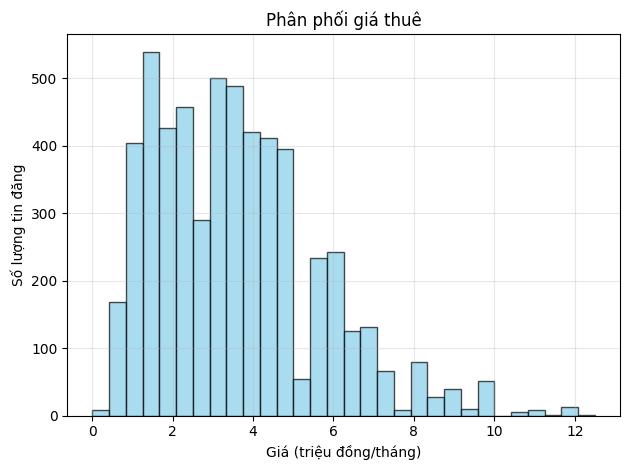

In [49]:
# Phân bố giá thuê
plt.hist(df['price_million'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Giá (triệu đồng/tháng)')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân phối giá thuê')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Phân phối giá thuê (triệu đồng/tháng)
### 1. Nhận xét chung
* **Lệch phải (Right-Skewed):** Phân phối giá thuê bị **lệch mạnh về bên phải**. Điều này có nghĩa là phần lớn các tin đăng phòng trọ có giá thuê thấp, nhưng có một số lượng nhỏ tin đăng có giá thuê rất cao, kéo đuôi phân phối về phía bên phải.
* **Đa đỉnh (Multimodal/Multiple Peaks):** Biểu đồ thể hiện nhiều đỉnh rõ rệt, đặc biệt là trong khoảng giá thuê phổ biến.

### 2. Giải thích chi tiết các khoảng giá
| Khoảng Giá (triệu VND) | Số lượng tin đăng | Nhận xét và Ý nghĩa |
| --- | --- | --- |
| **0.5 - 5.0** | **Chiếm đa số** | Đây là **khoảng giá thuê phổ biến nhất**, tập trung phần lớn dữ liệu (với nhiều cột cao trên 400-500 tin đăng). Điều này đại diện cho: <ul><li>Phòng trọ/Ký túc xá giá rẻ.</li><li>Các căn hộ mini/Phòng trọ có diện tích trung bình.</li></ul> |
| **1.5 - 2.5** | **Đỉnh cao nhất** | Có hai đỉnh rõ ràng tại khoảng này (gần 2.0 và 2.5 triệu). Đây có thể là **giá thuê điển hình** cho phòng trọ sinh viên, công nhân hoặc các phòng trọ nằm ở vị trí xa trung tâm hơn. |
| **3.5 - 4.5** | **Đỉnh phổ biến thứ hai** | Khoảng giá này đại diện cho các phòng trọ/căn hộ dịch vụ có diện tích lớn hơn, hoặc nằm ở các khu vực trung tâm, tiện nghi tốt hơn. |
| **5.5 - 7.5** | **Phân khúc trung bình - cao** | Số lượng tin đăng giảm đáng kể (chủ yếu 100 - 250 tin). Đây là phân khúc dành cho căn hộ 1 phòng ngủ nhỏ, studio hiện đại, hoặc nhà nguyên căn cho nhóm thuê. |
| **> 8.0** | **Phân khúc cao cấp** | Số lượng tin đăng rất ít (chỉ vài chục tin/tháng). Đây là các tin đăng về căn hộ cao cấp, nhà phố nguyên căn, hoặc biệt thự cho thuê. |

### Tóm tắt ý nghĩa
* **Thị trường cạnh tranh:** Thị trường phòng trọ **rất cạnh tranh** ở phân khúc **giá thấp** (< 5 triệu đồng/tháng).
* **Phân khúc đa dạng:** Sự xuất hiện của nhiều đỉnh cho thấy thị trường có nhiều **phân khúc sản phẩm riêng biệt** (ví dụ: phòng trọ thường giá 2 triệu, phòng trọ hiện đại giá 4 triệu).
* **Giá trị ngoại lai:** Mặc dù ít, nhưng các tin đăng giá rất cao (> 10 triệu) cho thấy có sự hiện diện của **phòng trọ/nhà ở cao cấp** trong tập dữ liệu (phù hợp với tính chất lệch phải).

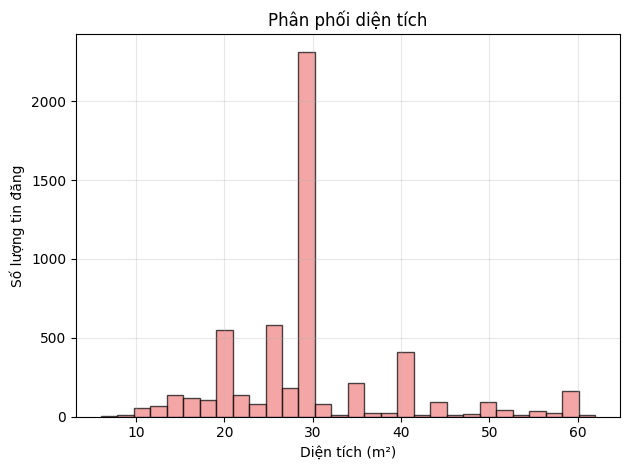

In [50]:
# Phân bố diện tích
plt.hist(df['area_m2'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân phối diện tích')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Phân phối diện tích $m^{2}$
Biểu đồ này cho thấy sự phân bố của số lượng tin đăng theo các diện tích phòng trọ khác nhau.

### Nhận xét & Giải thích
* **Phân phối Rất tập trung và đa đỉnh:** Dữ liệu có xu hướng tập trung vào các mốc diện tích cố định, tạo thành các cột/đỉnh rất cao và nhọn, không phải là phân phối chuẩn.
* **Đỉnh nổi bật nhất (Phòng trọ phổ thông):** Đỉnh cao nhất gần **30$m^{2}$** (với hơn 2200 tin đăng).
* **Giải thích:** Diện tích 30$m^{2}$ là diện tích phổ biến nhất, có thể đại diện cho các phòng trọ/căn hộ studio tiêu chuẩn, đáp ứng nhu cầu thuê của 1-2 người.


* **Các đỉnh quan trọng khác (Phòng nhỏ/Căn hộ):**
    * Khoảng **20$m^{2}$ và 25$m^{2}$**: Đại diện cho các phòng trọ nhỏ hơn, giá rẻ hơn.
    * Khoảng **40$m^{2}$**: Đại diện cho các căn hộ 1 phòng ngủ hoặc căn studio lớn, cao cấp hơn.


* **Ý nghĩa:** Dữ liệu diện tích thường được **làm tròn** đến các mốc số nguyên (15, 20, 25, 30, 40$m^{2}$), điều này giúp các nhà phát triển bất động sản xác định các **kích thước sản phẩm tối ưu** được thị trường chấp nhận nhiều nhất.

---

### Mối liên hệ giữa hai biểu đồ (Tổng hợp)
* Sự tập trung của *Diện tích 30$m^{2}$* có thể tương ứng với sự tập trung của **Giá thuê 2.5 - 4.0 triệu** đồng/tháng.
* Các phòng trọ có diện tích nhỏ hơn (15 - 20$m^{2}$) thường rơi vào khoảng giá **1.5 - 2.5 triệu** đồng/tháng.


## Boxplot

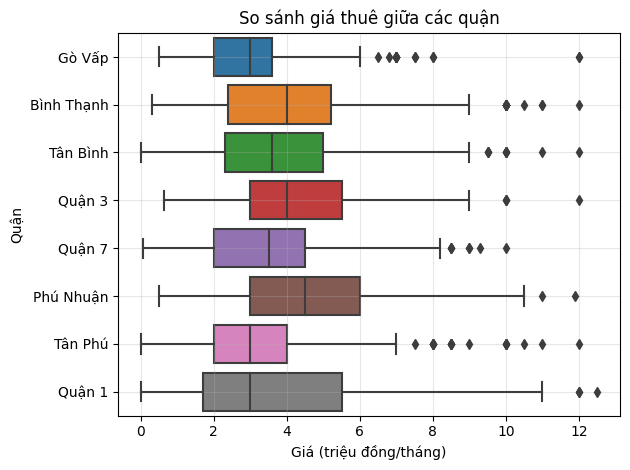

In [51]:
# So sánh giá giữa các quận

top_8_districts = df['district_extracted'].value_counts().head(8).index
filtered_df = df[df['district_extracted'].isin(top_8_districts)]
sns.boxplot(data=filtered_df, y='district_extracted', x='price_million', orient='h')
plt.xlabel('Giá (triệu đồng/tháng)')
plt.ylabel('Quận')
plt.title('So sánh giá thuê giữa các quận')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### So sánh giá thuê giữa các quận (Boxplot)
Biểu đồ Boxplot này so sánh phân bố giá thuê (Trung vị, Tứ phân vị, Ngoại lai) giữa 8 quận hàng đầu.

#### Nhận xét & Giải thích
* **Quận có giá thuê Trung vị (Median) Cao nhất:**
    * **Quận 1** có giá thuê trung vị cao nhất (đường kẻ đậm trong hộp, khoảng **4.5 - 5.0 triệu VND**).
    * **Phú Nhuận** và **Quận 3** cũng nằm trong nhóm cao (Trung vị khoảng 4.0 - 4.5 triệu VND).


* **Quận có giá thuê Trung vị Thấp nhất:**
    * **Gò Vấp** và **Tân Phú** có giá thuê trung vị thấp nhất (khoảng **3.0 triệu VND**).


* **Độ biến động (IQR - Khoảng Tứ phân vị):**
    * **Quận 1** và **Phú Nhuận** có IQR (chiều dài hộp) lớn, cho thấy giá thuê **rất đa dạng** và có nhiều loại hình phòng trọ/căn hộ khác nhau (từ bình dân đến cao cấp).
    * **Gò Vấp** có IQR hẹp hơn, cho thấy giá thuê tập trung hơn quanh mức trung vị, ít biến động hơn.


* **Giá trị ngoại lai (Outliers):** Tất cả các quận đều có nhiều điểm ngoại lai (kim cương đen) nằm ở phía trên, xác nhận sự tồn tại của các phòng trọ/căn hộ có giá thuê rất cao so với mặt bằng chung của quận đó.


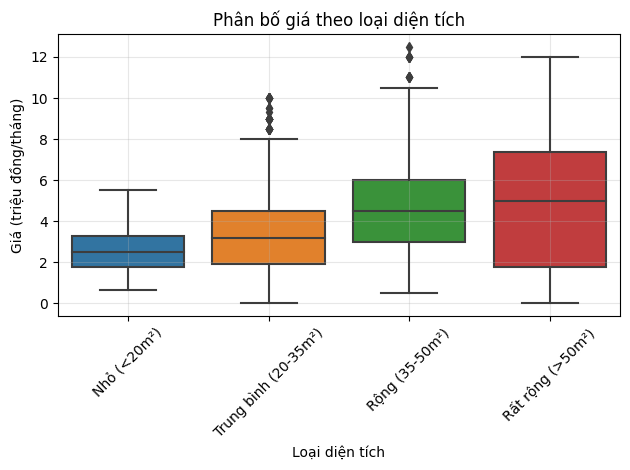

In [52]:
# Giá theo loại diện tích

sns.boxplot(data=df, x='size_category', y='price_million', 
            order=['Nhỏ (<20m²)', 'Trung bình (20-35m²)', 'Rộng (35-50m²)', 'Rất rộng (>50m²)'])
plt.xlabel('Loại diện tích')
plt.ylabel('Giá (triệu đồng/tháng)')
plt.title('Phân bố giá theo loại diện tích')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Phân bố giá theo Loại diện tích (Boxplot)

* **Nhận xét:** Biểu đồ Boxplot này cho thấy mối quan hệ trực tiếp giữa **diện tích và giá thuê** (Trung vị giá thuê tăng dần theo diện tích).
* **Giải thích:**
    * **Quan hệ Tăng trưởng:** **Giá thuê Trung vị tăng rõ rệt khi diện tích tăng:**
    * Nhóm **Nhỏ (<20$m^{2}$):** Trung vị khoảng 2.5 triệu VND.
    * Nhóm **Rất rộng (>50$m^{2}$):** Trung vị khoảng 5.0 triệu VND.


* **Độ biến động (IQR):**
    * Nhóm **Nhỏ** có IQR hẹp nhất, cho thấy giá thuê khá ổn định và ít biến động.
    * Nhóm **Rộng** và **Rất rộng** có IQR rộng hơn, cho thấy sự đa dạng lớn về chất lượng và loại hình (căn hộ dịch vụ, nhà nguyên căn,...) ở các phân khúc diện tích lớn.


* **Ý nghĩa:** Diện tích là yếu tố dự báo giá thuê quan trọng nhất.

## Scatter plot

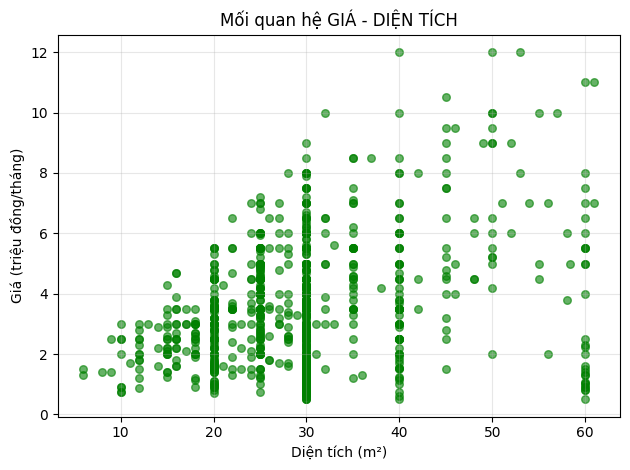

In [53]:
# Mối quan hệ giá – diện tích
# plt.subplot(3, 4, 4)
sample_df = df.sample(min(1000, len(df)), random_state=42)  # Lấy mẫu để biểu đồ rõ hơn
plt.scatter(sample_df['area_m2'], sample_df['price_million'], alpha=0.6, s=30, color='green')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá (triệu đồng/tháng)')
plt.title('Mối quan hệ GIÁ - DIỆN TÍCH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Mối quan hệ "GIÁ - DIỆN TÍCH" (Biểu đồ Scatter Plot)
* **Mối liên hệ:** Có một **mối quan hệ tuyến tính dương** rõ ràng giữa diện tích và giá thuê. Nói cách khác, diện tích càng lớn thì giá thuê càng có xu hướng cao hơn.
* **Sự tập trung:** Các điểm dữ liệu **tập trung dày đặc** theo chiều dọc tại các mốc diện tích cụ thể như 20$m^{2}$, 25$m^{2}$, 30$m^{2}$, và 40$m^{2}$. Điều này xác nhận sự **chuẩn hóa kích thước** sản phẩm trên thị trường (Phòng trọ thường được xây dựng theo các kích thước cố định).
* **Biến động giá:** Đối với cùng một diện tích (ví dụ 30$m^{2}$), giá thuê có **biến động rất lớn** (từ dưới 1.0 triệu đến gần 8.0 triệu đồng/tháng). Điều này cho thấy **vị trí, tiện nghi và chất lượng** (ví dụ: phòng trọ thường vs. căn hộ dịch vụ) là những yếu tố quan trọng quyết định giá thuê, không chỉ riêng diện tích.


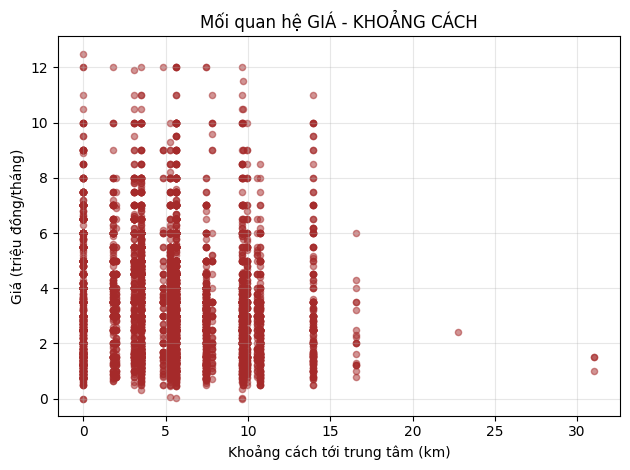

In [54]:
# Giá vs Khoảng cách tới trung tâm
# plt.subplot(3, 4, 11)
plt.scatter(df['distance_to_center_km'], df['price_million'], alpha=0.5, s=20, color='brown')
plt.xlabel('Khoảng cách tới trung tâm (km)')
plt.ylabel('Giá (triệu đồng/tháng)')
plt.title('Mối quan hệ GIÁ - KHOẢNG CÁCH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Mối quan hệ GIÁ - KHOẢNG CÁCH (Scatter Plot)
- **Xu hướng:** Không có mối quan hệ tuyến tính rõ ràng. Dữ liệu giá thuê không giảm đáng kể khi khoảng cách đến trung tâm tăng lên.
- **Giải thích:**
    - Giá cao ở mọi khoảng cách: Các tin đăng giá thuê cao (trên $8$ triệu VND) vẫn xuất hiện ở mọi khoảng cách (từ $0$ km đến $10$ km). Điều này chứng tỏ sự khác biệt về Quận/Khu vực (đã được thể hiện trong Boxplot dưới đây) có ảnh hưởng lớn hơn Khoảng cách tuyến tính đơn thuần.
    - Tập trung gần trung tâm: Dữ liệu tập trung dày đặc nhất trong phạm vi $< 10\ km$, nơi có hầu hết các tin đăng.

## Heatmap

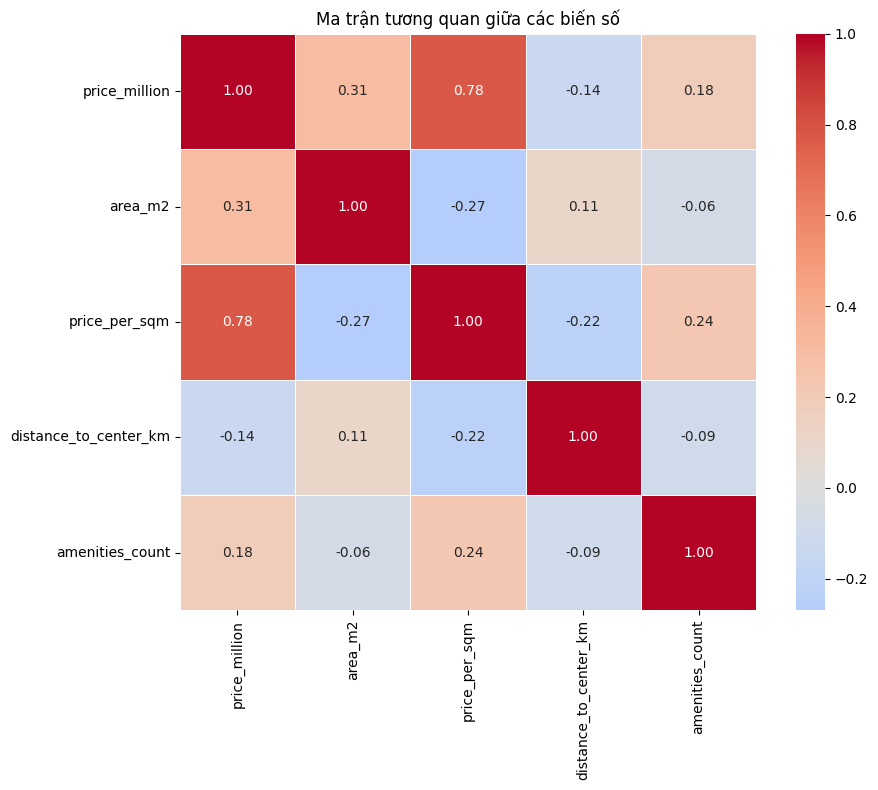

In [55]:
# Ma trận tương quan giữa các biến
numeric_cols = ['price_million', 'area_m2', 'price_per_sqm', 'distance_to_center_km', 'amenities_count']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

### Ma trận Tương quan (Heatmap)
| Mối quan hệ | Hệ số Tương quan (r) | Ý nghĩa trong Phân tích |
| --- | --- | --- |
| **Giá thuê** với **Giá/m$^2$** | **0.78** (Mạnh, Dương) | **Mối tương quan mạnh nhất.** Giá thuê được quyết định bởi đơn giá trên mỗi mét vuông. |
| **Giá thuê** với **Diện tích** | **0.31** (Trung bình, Dương) | Diện tích lớn hơn thì giá thuê có xu hướng cao hơn. |
| **Giá thuê** với **Khoảng cách** | **-0.14** (Yếu, Âm) | Khoảng cách đến trung tâm không phải là yếu tố dự báo giá mạnh, cho thấy sự khác biệt về Quận (đã thấy trong Boxplot) quan trọng hơn khoảng cách tuyến tính. |
| **Giá/m$^2$** với **Diện tích** | **-0.27** (Trung bình, Âm) | **Càng thuê diện tích lớn, đơn giá/m$^2$ càng có xu hướng rẻ hơn.** |



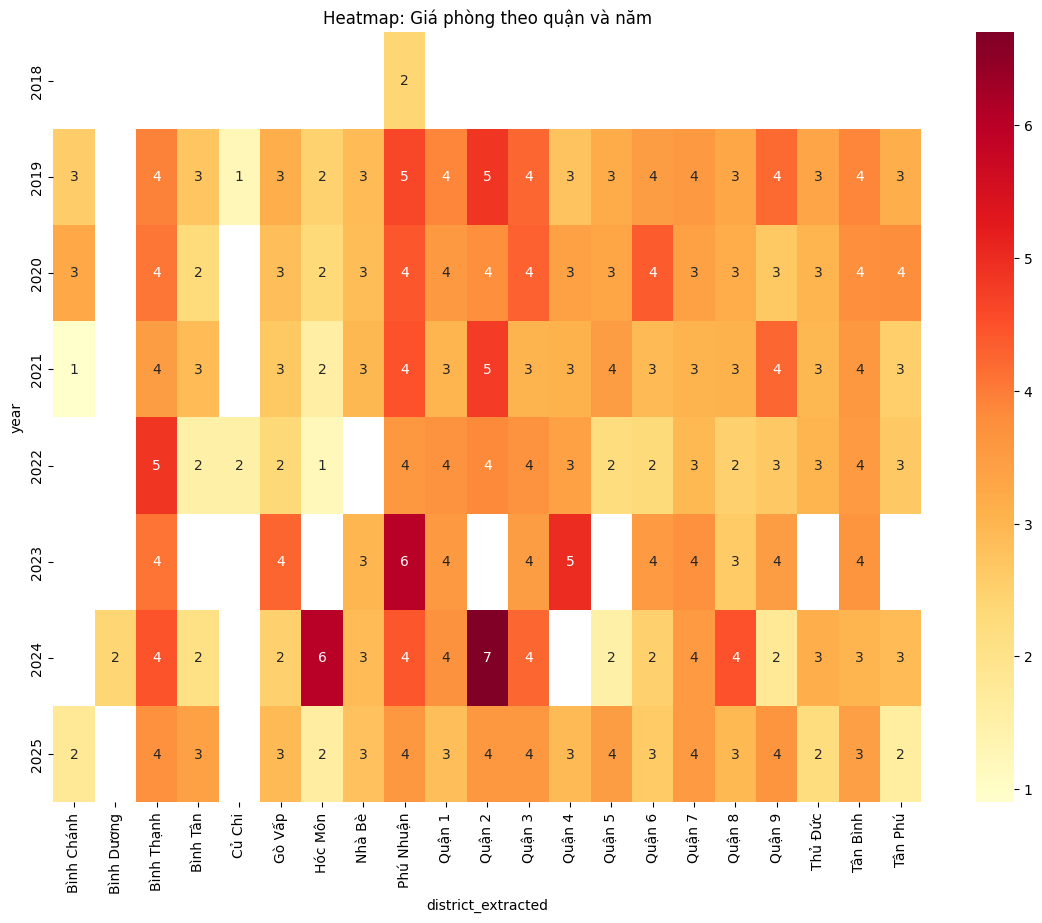

In [56]:
pivot_df = df.groupby(['year', 'district_extracted'])['price_million'].mean().unstack()

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title("Heatmap: Giá phòng theo quận và năm")
plt.show()


### Nhận xét & Giải thích Heatmap: Giá phòng theo Quận & Năm
Biểu đồ này rất quan trọng vì nó cho thấy **sự biến động của giá thuê theo thời gian** và **sự khác biệt giữa các quận** trong dài hạn.

#### 1. Phân tích Theo Quận (Biến động không gian)
* **Các Quận Luôn Đắt Đỏ (Màu Đỏ đậm):**
    * **Quận 1** và **Phú Nhuận** luôn duy trì mức giá cao nhất trong hầu hết các năm (mức 4 đến 6). Giá phòng ở Quận 1 đạt đỉnh cao nhất là **6 triệu/tháng** vào năm 2023.
    * **Quận 3** và **Quận Bình Thạnh** cũng duy trì mức giá tương đối cao và ổn định (mức 3-4).


* **Các Quận Có Giá Ổn Định và Thấp hơn (Màu Vàng/Cam nhạt):**
    * Các quận ngoại thành hoặc rìa như **Gò Vấp, Tân Phú, Bình Tân, Hóc Môn, Củ Chi** thường xuyên ở mức giá thấp (1-3 triệu/tháng).
    * **Tân Bình** và **Quận 7** duy trì mức giá trung bình (3-4 triệu/tháng).


* **Tâm Điểm Tăng Giá Cục Bộ:**
    * **Quận 1** đạt giá **7 triệu/tháng** vào năm 2024, là mức giá cao nhất trong toàn bộ dữ liệu.
    * **Quận 2** cũng có sự tăng giá mạnh vào các năm 2019-2021 (mức 4-5).



#### 2. Phân tích Theo Năm (Biến động thời gian)
* **Giá thuê có xu hướng Tăng đều:** Nhìn chung, mức giá thuê trung vị của các quận đều có xu hướng tăng nhẹ qua các năm, thể hiện sự tăng trưởng tự nhiên của thị trường bất động sản.
* **Sự Sụt Giảm Tạm Thời (Giai đoạn 2020-2022):**
    * Một số quận trung tâm như **Quận 1, Quận 2, Quận 3, Quận 4** có dấu hiệu **giảm nhẹ giá thuê** hoặc duy trì ở mức ổn định trong giai đoạn 2020-2022. Điều này có thể phản ánh tác động của đại dịch COVID-19 làm giảm nhu cầu thuê tại các khu vực trung tâm.
    * Ví dụ: Quận 1 giảm từ 5 triệu (2019) xuống 4 triệu (2020) và 3 triệu (2021).


* **Sự Phục Hồi và Tăng Tốc (Giai đoạn 2023-2024):**
    * Hầu hết các quận đều có **sự phục hồi mạnh mẽ** và đạt đỉnh giá vào năm 2023 và 2024. Ví dụ: Quận 1 tăng vọt lên 6 triệu (2023) và 7 triệu (2024). Điều này cho thấy thị trường đã phục hồi hoàn toàn sau đại dịch.



### Tổng kết ý nghĩa
1. **Vị trí quyết định giá trị cốt lõi:** Các quận trung tâm (Q1, Phú Nhuận) luôn có mức giá cao hơn nhiều so với các quận rìa, bất chấp biến động hàng năm.
2. **Tính chu kỳ:** Giá thuê phản ánh các sự kiện kinh tế lớn (giảm nhẹ trong giai đoạn đại dịch 2020-2021 và phục hồi mạnh mẽ sau đó).
3. **Điểm nóng:** **Quận 1** là nơi có giá thuê biến động mạnh nhất và đạt mức cao nhất, cho thấy đây là thị trường cao cấp và nhạy cảm nhất.


## Bar chart

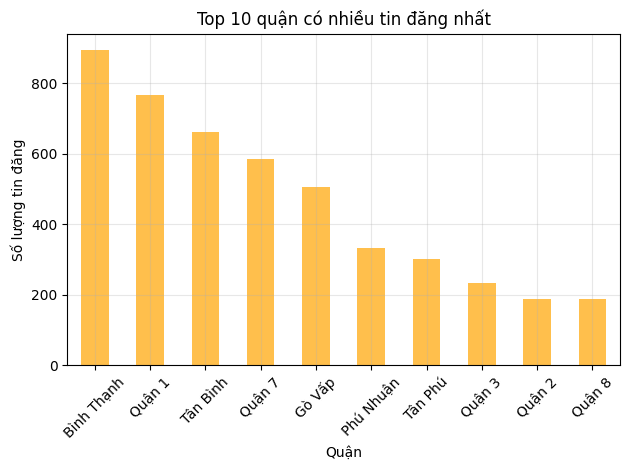

In [57]:
# Số lượng tin đăng theo quận

df['district_extracted'].value_counts().head(10).plot(kind='bar', color='orange', alpha=0.7)
plt.xlabel('Quận')
plt.ylabel('Số lượng tin đăng')
plt.title('Top 10 quận có nhiều tin đăng nhất')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét & Giải thích biểu đồ: Top 10 quận có nhiều tin đăng nhất
Biểu đồ này cho thấy sự tập trung của nguồn cung phòng trọ (số lượng tin đăng) tại 10 quận có hoạt động cho thuê sôi nổi nhất.

#### 1. Nhận xét Chung
* **Phân bổ Nguồn cung:** Nguồn cung phòng trọ **tập trung cao độ** ở một số quận nhất định, đặc biệt là các quận gần trung tâm hoặc có mật độ dân số/sinh viên cao.
* **Sự chênh lệch:** Có sự chênh lệch lớn giữa quận có nhiều tin đăng nhất (Bình Thạnh) và các quận cuối bảng (Quận 2, Quận 8).

#### 2. Giải thích chi tiết các quận dẫn đầu
| Quận | Số lượng Tin đăng | Ý nghĩa |
| --- | --- | --- |
| **Bình Thạnh** | **~900** | **Quận dẫn đầu về nguồn cung.** Bình Thạnh là khu vực giáp ranh Quận 1, có nhiều trường đại học lớn và khu văn phòng, tạo ra nhu cầu thuê khổng lồ. Đây là thị trường rất sôi động. |
| **Quận 1** | **~770** | Mặc dù có giá thuê cao (như đã thấy trong Boxplot), Quận 1 vẫn có nguồn cung lớn, chủ yếu là căn hộ dịch vụ và phòng trọ cao cấp, phục vụ người lao động trẻ, chuyên gia và người nước ngoài. |
| **Tân Bình** | **~670** | Vị trí gần sân bay và là cửa ngõ đi các quận, Tân Bình thu hút một lượng lớn người thuê làm việc tại các khu công nghiệp/sân bay và văn phòng. |
| **Quận 7** | **~580** | Nguồn cung tập trung ở các khu vực sinh viên và các khu căn hộ mới phát triển. |
| **Gò Vấp** | **~500** | Quận này cung cấp nguồn phòng trọ phổ thông, giá rẻ hơn, phù hợp cho phân khúc công nhân, sinh viên và gia đình. |

### Tổng kết ý nghĩa
* **Địa điểm Đầu tư Tiềm năng:** **Bình Thạnh** và **Quận 1** là nơi có hoạt động giao dịch và đăng tin mạnh nhất, cho thấy tính thanh khoản cao của thị trường thuê ở các quận này.
* **Mối liên hệ giữa Giá và Nguồn cung:** Mặc dù **Quận 1** có giá thuê cao nhất (theo Boxplot và Heatmap), nó vẫn nằm trong top 2 nguồn cung, chứng tỏ nhu cầu thuê phòng trọ chất lượng cao tại trung tâm là rất lớn. Ngược lại, **Quận 3** có giá cao nhưng nguồn cung thấp hơn (chỉ ~250 tin), có thể do quỹ đất hạn chế.

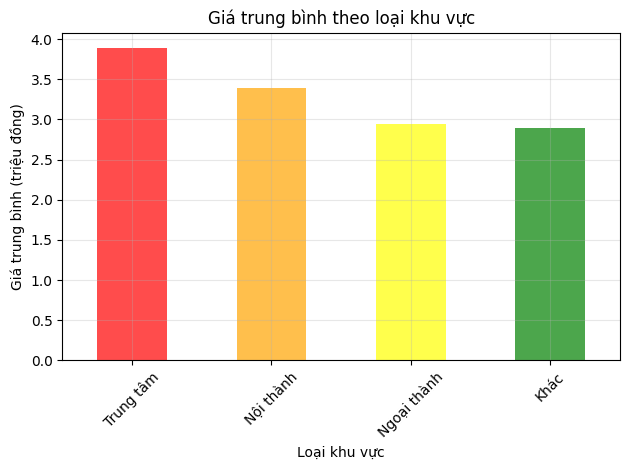

In [58]:
# Giá trung bình theo khu vực

area_price = df.groupby('area_type')['price_million'].mean().sort_values(ascending=False)
area_price.plot(kind='bar', color=['red', 'orange', 'yellow', 'green'], alpha=0.7)
plt.xlabel('Loại khu vực')
plt.ylabel('Giá trung bình (triệu đồng)')
plt.title('Giá trung bình theo loại khu vực')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét & Giải thích biểu đồ: Giá trung bình theo loại khu vực
Biểu đồ này so sánh mức giá thuê trung bình (triệu đồng/tháng) dựa trên việc phân loại các quận thành các nhóm khu vực (Trung tâm, Nội thành, Ngoại thành, Khác).

#### 1. Nhận xét chung
* **Mối quan hệ tuyến tính ngược:** Giá thuê trung bình có xu hướng **giảm dần** khi khu vực di chuyển từ **Trung tâm** ra **Ngoại thành**. Điều này phù hợp với logic thị trường bất động sản.
* **Sự chênh lệch rõ rệt:** Giá thuê trung bình của khu vực **Trung tâm** cao hơn đáng kể so với khu vực **Ngoại thành**.

#### 2. Giải thích chi tiết
| Loại khu vực | Giá trung bình (triệu VND) | Ý nghĩa |
| --- | --- | --- |
| **Trung tâm** | **$\approx$ 3.9** | **Khu vực có giá thuê trung bình cao nhất.** Bao gồm các quận lõi (như Q1, Q3), nơi tập trung nhiều công sở, tiện ích và giao thông thuận tiện. |
| **Nội thành** | **$\approx$ 3.4** | Giá thuê giảm nhẹ so với Trung tâm. Đây là các khu vực bao quanh trung tâm (như Bình Thạnh, Phú Nhuận, Tân Bình, Q7), nơi cân bằng giữa tiện ích và chi phí. |
| **Ngoại thành** | **$\approx$ 3.0** | **Khu vực có giá thuê trung bình thấp nhất.** Bao gồm các quận xa trung tâm hơn (như Gò Vấp, Tân Phú, các huyện), phù hợp với người thuê có ngân sách eo hẹp hơn. |
| **Khác** | **$\approx$ 2.9** | Mức giá tương đương hoặc thấp hơn Ngoại thành, đại diện cho các khu vực có nhu cầu thuê chuyên biệt hoặc vị trí rất xa. |

### Tổng kết ý nghĩa
* **Khoảng cách và vị trí là yếu tố chính:** Mức chênh lệch rõ ràng giữa **Trung tâm** (3.9 triệu) và **Ngoại thành** (3.0 triệu) cho thấy **Vị trí** là yếu tố quyết định hàng đầu đối với giá thuê trung bình.
* **Định giá khu vực:** Người thuê sẵn sàng trả thêm khoảng **0.9 - 1.0 triệu đồng/tháng** để thuê phòng ở khu vực **Trung tâm** so với khu vực **Ngoại thành**.


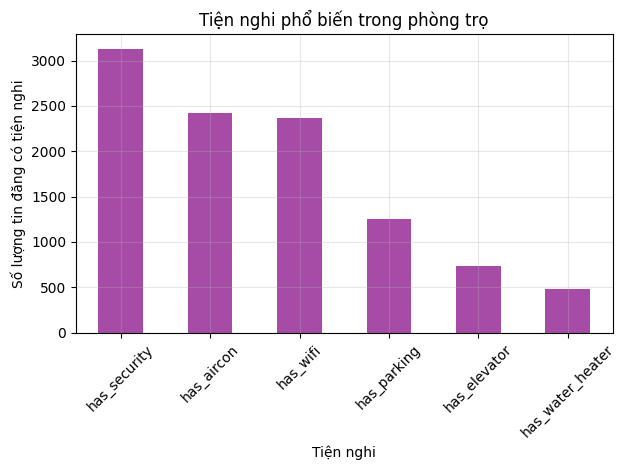

In [59]:
# Tiện nghi phổ biến

amenities_sum = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator']].sum()
amenities_sum.sort_values(ascending=False).plot(kind='bar', color='purple', alpha=0.7)
plt.xlabel('Tiện nghi')
plt.ylabel('Số lượng tin đăng có tiện nghi')
plt.title('Tiện nghi phổ biến trong phòng trọ')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

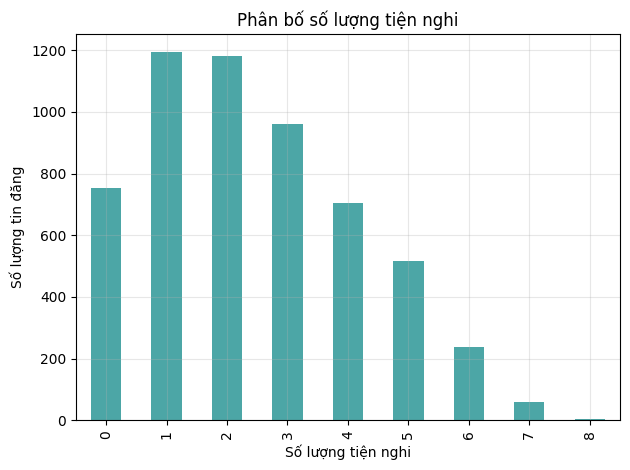

In [60]:
# Số lượng tiện nghi

df['amenities_count'].value_counts().sort_index().plot(kind='bar', color='teal', alpha=0.7)
plt.xlabel('Số lượng tiện nghi')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân bố số lượng tiện nghi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pie chart

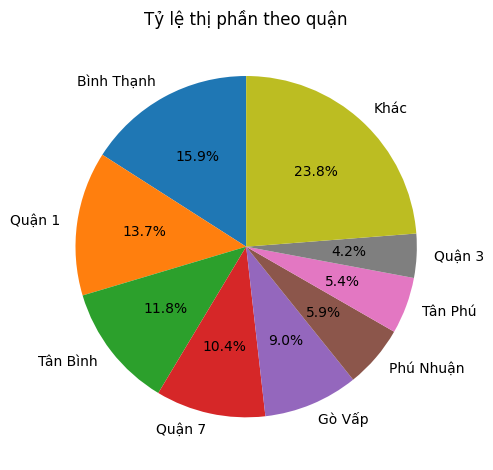

In [61]:
# Tỷ lệ thị phần quận

top_8_pie = df['district_extracted'].value_counts().head(8)
other_count = len(df) - top_8_pie.sum()
pie_data = pd.concat([top_8_pie, pd.Series({'Khác': other_count})])
pie_data.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Tỷ lệ thị phần theo quận')
plt.tight_layout()
plt.show()

## Plotly Scatter Mapbox

In [62]:
import plotly.express as px

# Tính giá trung bình từng quận theo từng năm
map_df = df.groupby(['year', 'district_extracted', 'lat', 'lng'])['price_million'].mean().reset_index()

fig = px.scatter_mapbox(
    map_df,
    lat="lat",
    lon="lng",
    color="price_million",
    size="price_million",
    animation_frame="year",
    hover_name="district_extracted",
    hover_data={"price_million": True, "lat": False, "lng": False},
    color_continuous_scale="YlOrRd",
    zoom=10,
    height=650
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="Biến động giá phòng theo từng khu vực & thời gian tại TP.HCM",
    margin={"r":0,"t":50,"l":0,"b":0}
)
fig.write_html("map_hcm_price.html")
# fig.show()


In [63]:
from IPython.display import IFrame

IFrame(src="map_hcm_price.html", width=1000, height=700)


## Phát hiện insight

In [64]:
# A. Quận có giá thuê cao nhất/thấp nhất

# Top 5 quận giá cao nhất
top_5_expensive = df.groupby('district_extracted')['price_million'].mean().nlargest(5)
print(" TOP 5 QUẬN CÓ GIÁ CAO NHẤT:")
for i, (district, price) in enumerate(top_5_expensive.items(), 1):
    count = len(df[df['district_extracted'] == district])
    print(f"  {i}. {district}: {price:.1f} triệu/tháng ({count} tin)")

# Top 5 quận giá thấp nhất  
top_5_cheap = df.groupby('district_extracted')['price_million'].mean().nsmallest(5)
print("\n TOP 5 QUẬN CÓ GIÁ THẤP NHẤT:")
for i, (district, price) in enumerate(top_5_cheap.items(), 1):
    count = len(df[df['district_extracted'] == district])
    print(f"  {i}. {district}: {price:.1f} triệu/tháng ({count} tin)")

print("\n B. TƯƠNG QUAN GIỮA DIỆN TÍCH ")
corr_area_price = df['area_m2'].corr(df['price_million'])

print(f"Tương quan Diện tích - Giá: {corr_area_price:.3f}")

# Phân tích theo nhóm diện tích
print("\n PHÂN TÍCH THEO NHÓM DIỆN TÍCH:")
size_group_analysis = df.groupby('size_category').agg({
    'price_million': ['count', 'mean', 'median'],
    'area_m2': 'mean',
    'price_per_sqm': 'mean'
}).round(2)

display(size_group_analysis)

# C. Mức độ tập trung tin đăng theo khu vực
print("\n C. MỨC ĐỘ TẬP TRUNG TIN ĐĂNG THEO KHU VỰC")

# Phân bố theo khu vực
area_concentration = df['area_type'].value_counts()
print(" PHÂN BỐ TIN ĐĂNG THEO KHU VỰC:")
for area_type, count in area_concentration.items():
    percentage = count / len(df) * 100
    avg_price = df[df['area_type'] == area_type]['price_million'].mean()
    print(f"  {area_type}: {count} tin ({percentage:.1f}%) - Giá TB: {avg_price:.1f} triệu")

# Top quận có nhiều tin đăng nhất
print(f"\n TOP QUẬN CÓ NHIỀU TIN ĐĂNG NHẤT:")
top_districts = df['district_extracted'].value_counts().head(5)
for i, (district, count) in enumerate(top_districts.items(), 1):
    percentage = count / len(df) * 100
    avg_price = df[df['district_extracted'] == district]['price_million'].mean()
    print(f"  {i}. {district}: {count} tin ({percentage:.1f}%) - Giá TB: {avg_price:.1f} triệu")

# D. INSIGHTS QUAN TRỌNG
print("\n D. INSIGHTS QUAN TRỌNG")

# 1. Insight về giá
price_ratio = top_5_expensive.iloc[0] / top_5_cheap.iloc[0]
print(f"1. CHÊNH LỆCH GIÁ: Quận đắt nhất đắt gấp {price_ratio:.1f} lần quận rẻ nhất")

# 2. Insight về mật độ
most_concentrated = top_districts.index[0]
concentration_rate = top_districts.iloc[0] / len(df) * 100
print(f"2. TẬP TRUNG ĐỊA LÝ: {most_concentrated} chiếm {concentration_rate:.1f}% tổng số tin")

# 3. Insight về tương quan
if corr_area_price > 0.5:
    strength = "mạnh"
elif corr_area_price > 0.3:
    strength = "trung bình" 
else:
    strength = "yếu"
print(f"3. TƯƠNG QUAN: Mối quan hệ diện tích - giá có tương quan {strength}")

# 4. Insight về tiện nghi
avg_amenities = df['amenities_count'].mean()
print(f"4. TIỆN NGHI: Trung bình mỗi phòng có {avg_amenities:.1f} tiện nghi")

# 5. Insight về khu vực
most_expensive_area = df.groupby('area_type')['price_million'].mean().idxmax()
print(f"5. KHU VỰC: {most_expensive_area} có giá thuê cao nhất")


 TOP 5 QUẬN CÓ GIÁ CAO NHẤT:
  1. Phú Nhuận: 4.5 triệu/tháng (332 tin)
  2. Quận 2: 4.3 triệu/tháng (187 tin)
  3. Quận 3: 4.2 triệu/tháng (234 tin)
  4. Bình Thạnh: 4.0 triệu/tháng (895 tin)
  5. Tân Bình: 3.8 triệu/tháng (661 tin)

 TOP 5 QUẬN CÓ GIÁ THẤP NHẤT:
  1. Củ Chi: 1.3 triệu/tháng (3 tin)
  2. Bình Dương: 2.4 triệu/tháng (1 tin)
  3. Hóc Môn: 2.4 triệu/tháng (19 tin)
  4. Bình Tân: 2.5 triệu/tháng (184 tin)
  5. Bình Chánh: 2.9 triệu/tháng (45 tin)

 B. TƯƠNG QUAN GIỮA DIỆN TÍCH 
Tương quan Diện tích - Giá: 0.310

 PHÂN TÍCH THEO NHÓM DIỆN TÍCH:


price_million              area_m2 price_per_sqm
                             count  mean median    mean          mean
size_category                                                        
Nhỏ (<20m²)                    499  2.55    2.5   14.79          0.17
Rất rộng (>50m²)               370  5.06    5.0   55.96          0.09
Rộng (35-50m²)                 809  4.76    4.5   39.52          0.12
Trung bình (20-35m²)          3934  3.37    3.2   27.41          0.12


 C. MỨC ĐỘ TẬP TRUNG TIN ĐĂNG THEO KHU VỰC
 PHÂN BỐ TIN ĐĂNG THEO KHU VỰC:
  Trung tâm: 3090 tin (55.1%) - Giá TB: 3.9 triệu
  Nội thành: 1823 tin (32.5%) - Giá TB: 3.4 triệu
  Ngoại thành: 616 tin (11.0%) - Giá TB: 2.9 triệu
  Khác: 83 tin (1.5%) - Giá TB: 2.9 triệu

 TOP QUẬN CÓ NHIỀU TIN ĐĂNG NHẤT:
  1. Bình Thạnh: 895 tin (15.9%) - Giá TB: 4.0 triệu
  2. Quận 1: 767 tin (13.7%) - Giá TB: 3.7 triệu
  3. Tân Bình: 661 tin (11.8%) - Giá TB: 3.8 triệu
  4. Quận 7: 584 tin (10.4%) - Giá TB: 3.5 triệu
  5. Gò Vấp: 504 tin (9.0%) - Giá TB: 3.0 triệu

 D. INSIGHTS QUAN TRỌNG
1. CHÊNH LỆCH GIÁ: Quận đắt nhất đắt gấp 3.4 lần quận rẻ nhất
2. TẬP TRUNG ĐỊA LÝ: Bình Thạnh chiếm 15.9% tổng số tin
3. TƯƠNG QUAN: Mối quan hệ diện tích - giá có tương quan trung bình
4. TIỆN NGHI: Trung bình mỗi phòng có 2.4 tiện nghi
5. KHU VỰC: Trung tâm có giá thuê cao nhất


# PHẦN 5: PHÂN CỤM/ PHÂN NHÓM (CLUSTERING/ CLASSIFICATION - NÂNG CAO)

In [65]:
df_clear = pd.DataFrame(df)
df_clear.to_csv('results_hcm_clear.csv',index = False)

### Giải Thích Chi Tiết Về Silhouette Score

Silhouette Score (hay còn gọi là **Silhouette Coefficient**) là một chỉ số đánh giá chất lượng phân cụm (clustering) trong học máy không giám sát. Nó được sử dụng để đo lường mức độ **"tách biệt"** và **"chặt chẽ"** của các cụm dữ liệu, giúp xác định số lượng cụm tối ưu ($k$) trong các thuật toán như K-Means, DBSCAN hoặc Hierarchical Clustering.

-----

#### 1\. Khái Niệm Cơ Bản

  * **Mục đích**: Đánh giá xem một điểm dữ liệu có được phân cụm **"đúng"** hay không, bằng cách so sánh:
      * **Sự tương đồng nội bộ (Cohesion)**: Điểm dữ liệu gần các điểm khác trong cùng cụm bao nhiêu?
      * **Sự tách biệt ngoại bộ (Separation)**: Điểm dữ liệu xa các điểm ở cụm khác bao nhiêu?
  * **Phạm vi giá trị**: Từ **-1 đến 1**:
      * **$\approx 1$**: Cụm hoàn hảo (tách biệt rõ, chặt chẽ).
      * **$\approx 0$**: Điểm nằm ở ranh giới giữa hai cụm (có thể nên gộp cụm).
      * **$\approx -1$**: Điểm bị phân cụm sai (gần cụm khác hơn cụm của nó).

-----

#### 2\. Công Thức Toán Học Chi Tiết (Tối ưu cho Markdown)

Silhouette Score $s(i)$ của một điểm dữ liệu $i$ là phép so sánh được chuẩn hóa giữa khoảng cách tách biệt $b(i)$ và khoảng cách nội bộ $a(i)$.

##### **Công thức chung:**

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

> *Trong môi trường Markdown không hỗ trợ LaTeX, công thức có thể được diễn giải như sau:*

```
s(i) = [ b(i) - a(i) ] / max( a(i), b(i) )
```

##### **Tính toán $a(i)$ – Intra-cluster distance (Khoảng cách nội bộ):**

Đây là khoảng cách trung bình từ điểm $i$ đến **tất cả các điểm khác** trong cùng cụm $C(i)$.
$$\Large a(i) = \frac{1}{|C(i)| - 1} \sum_{j \in C(i), j \neq i} d(i, j)$$

  * Nếu $a(i)$ nhỏ → **Cohesion tốt** (Điểm $i$ chặt chẽ với cụm của nó).

##### **Tính toán $b(i)$ – Inter-cluster distance (Khoảng cách ngoại bộ):**

Đây là khoảng cách trung bình **nhỏ nhất** từ điểm $i$ đến các điểm ở bất kỳ cụm khác $C_k$ nào.
$$\Large b(i) = \min_{k \neq C(i)} \left( \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j) \right)$$

  * Nếu $b(i)$ lớn → **Separation tốt** (Điểm $i$ xa các cụm khác).

**Silhouette trung bình toàn cục:**

$$S = \frac{1}{n} \sum_{i=1}^n s(i)$$

-----

#### 3\. Ý Nghĩa Của Các Giá Trị

| Giá Trị $S$ | Ý Nghĩa | Hành Động Khuyến Nghị |
|:-----------:|:---------|:-----------------------|
| **\> 0.7** | Cụm rất tốt, tách biệt cao | Giữ nguyên $k$ (Lý tưởng cho data sạch). |
| **0.5 - 0.7** | Cụm tốt, cohesion/separation cân bằng | Chấp nhận, kiểm tra outliers. |
| **0.2 - 0.5** | Cụm chấp nhận được | OK cho K-Means với data thực tế có nhiễu. |
| **0 - 0.2** | Cụm yếu, nhiều điểm ranh giới | Tăng/giảm $k$; thử thuật toán khác (ví dụ DBSCAN). |
| **\< 0** | Cụm sai (Misclustering) | Thay thuật toán hoặc tiền xử lý data. |

> **Ví dụ của bạn (k=5, $S \approx 0.256$):** Đây là mức **chấp nhận được** đối với dữ liệu thực tế (như giá thuê) có tính nhiễu cao, cho thấy cụm vẫn tách biệt vừa phải.

-----

#### 4\. Silhouette Plot (Trực Quan Hóa)

Silhouette Plot là cách tốt nhất để xem chi tiết chất lượng phân cụm.

  * **Chiều rộng của cụm (bar):** Biểu thị số lượng điểm trong cụm.
  * **Độ dài của mỗi đường (line):** Là $s(i)$ của một điểm.
      * Các đường dài, mượt, và gần $1.0$: Cụm chặt chẽ và tách biệt tốt.
      * Các đường ngắn, hỗn loạn, hoặc đi dưới đường trung bình (đường nét đứt màu đỏ): Cụm có vấn đề (điểm ranh giới hoặc phân cụm sai).
  * **Đường nét đứt (đỏ):** Thể hiện **Silhouette Score trung bình** ($S$).

Sử dụng Silhouette Plot giúp bạn xác định cụm nào đang hoạt động kém ngay cả khi $S$ trung bình cao.

-----

#### 5\. Ưu Điểm Và Nhược Điểm

**Ưu điểm**:

  * **Không giám sát**: Không cần nhãn, dễ dùng cho bất kỳ thuật toán clustering nào.
  * **Toàn diện**: Kết hợp cả cohesion và separation.
  * **Trực quan hóa**: Dễ dàng vẽ Silhouette Plot để kiểm tra chất lượng từng cụm.

**Nhược điểm**:

  * **Phụ thuộc khoảng cách**: Chỉ tốt với khoảng cách Euclidean (kém với data high-dimensional hoặc non-spherical clusters).
  * **Tốn tài nguyên**: Độ phức tạp tính toán là $O(n^2)$ cho data lớn ($n$: số điểm dữ liệu).
  * **Nhạy cảm noise/outliers**: Các điểm ngoại lai có thể kéo $S$ trung bình xuống.

In [66]:
# Tiền xử lý cho phân cụm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mã hóa quận/huyện
le_district = LabelEncoder()
df['district_encoded'] = le_district.fit_transform(df['district_extracted'].fillna('Unknown'))

print(f"Đã encode {len(le_district.classes_)} quận/huyện:")
for i, district in enumerate(le_district.classes_):
    print(f"  {district}: {i}")

# Features cho clustering
features_cluster = ['price_million', 'area_m2', 'distance_to_center_km', 'amenities_count']

X_cluster = df[features_cluster].copy()
print(f"Số dòng trước khi xử lý: {len(X_cluster)}")
print(f"Các features: {features_cluster}")

print("\nThống kê ban đầu:")
print(X_cluster.describe())

# Loại bỏ missing values nếu có
X_cluster = X_cluster.dropna()
print(f"Số dòng còn lại: {len(X_cluster)}")

Đã encode 21 quận/huyện:
  Bình Chánh: 0
  Bình Dương: 1
  Bình Thạnh: 2
  Bình Tân: 3
  Củ Chi: 4
  Gò Vấp: 5
  Hóc Môn: 6
  Nhà Bè: 7
  Phú Nhuận: 8
  Quận 1: 9
  Quận 2: 10
  Quận 3: 11
  Quận 4: 12
  Quận 5: 13
  Quận 6: 14
  Quận 7: 15
  Quận 8: 16
  Quận 9: 17
  Thủ Đức: 18
  Tân Bình: 19
  Tân Phú: 20
Số dòng trước khi xử lý: 5612
Các features: ['price_million', 'area_m2', 'distance_to_center_km', 'amenities_count']

Thống kê ban đầu:
       price_million      area_m2  distance_to_center_km  amenities_count
count    5612.000000  5612.000000            5612.000000      5612.000000
mean        3.606869    29.913443               5.374633         2.445296
std         2.052547     9.826273               3.616153         1.739300
min         0.003100     6.000000               0.000000         0.000000
25%         2.000000    25.000000               3.047750         1.000000
50%         3.400000    30.000000               5.271091         2.000000
75%         4.800000    30.000000   

## 5.1. Thực nghiệm 1: Phân khúc Thị trường Thuê trọ (Trả lời câu 1, 5)

### Mục tiêu
Nhóm các phòng trọ thành các phân khúc tương đồng dựa trên giá (**price_million**), diện tích (**area_m2**), vị trí (**district_extracted** mã hóa) và tiện nghi (**amenities_count**). Xác định phân khúc nào mang lại giá trị tốt nhất (tỷ lệ giá/diện tích/vị trí thấp nhất, phù hợp cho sinh viên).

### Phương pháp

- **K-Means:** Phân cụm cứng với số cụm tối ưu (Elbow Method). Sử dụng Euclidean distance để đo lường; phân tích khoảng cách trung tâm cụm đến các features gốc để xác định yếu tố ảnh hưởng mạnh nhất (ví dụ: nếu khoảng cách lớn nhất trên feature giá, thì giá ảnh hưởng nhiều hơn).
- **DBSCAN:** Phân cụm mật độ để phát hiện outlier (phòng trọ bất thường như giá cao bất hợp lý).
- **Features:** **price_million**, **area_m2**, **amenities_count**, **district_encoded** (LabelEncoder cho quận).
- **Tiền xử lý:** Scale StandardScaler; loại bỏ outliers (IQR cho giá và diện tích).

In [67]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [68]:
# XÁC ĐỊNH SỐ CỤM TỐI ƯU (K-Means)
inertias = []
sil_scores = []
db_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    # Tính silhouette score
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(sil_score)
    
    # Tính Davies-Bouldin score (thấp hơn = tốt hơn)
    db_score = davies_bouldin_score(X_scaled, kmeans.labels_)
    db_scores.append(db_score)
    
    print(f"k = {k}: Inertia = {kmeans.inertia_:.2f}, Silhouette = {sil_score:.3f}, DB Index = {db_score:.3f}")


k = 2: Inertia = 17497.78, Silhouette = 0.227, DB Index = 1.710
k = 3: Inertia = 14094.70, Silhouette = 0.239, DB Index = 1.402
k = 4: Inertia = 11500.28, Silhouette = 0.247, DB Index = 1.258
k = 5: Inertia = 10229.15, Silhouette = 0.256, DB Index = 1.242
k = 6: Inertia = 9360.91, Silhouette = 0.232, DB Index = 1.301
k = 7: Inertia = 8636.67, Silhouette = 0.219, DB Index = 1.326
k = 8: Inertia = 8079.53, Silhouette = 0.217, DB Index = 1.338
k = 9: Inertia = 7607.72, Silhouette = 0.215, DB Index = 1.311
k = 10: Inertia = 7213.64, Silhouette = 0.223, DB Index = 1.265


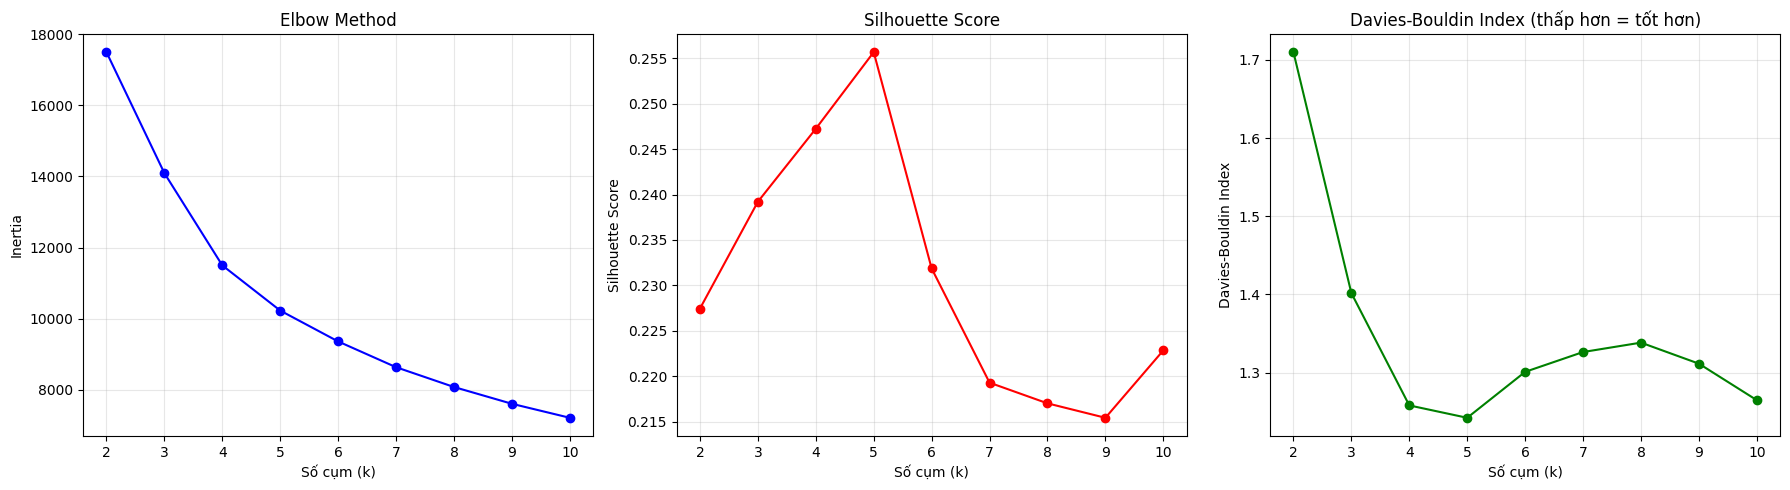

In [69]:
# Visualize Elbow và Silhouette
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Số cụm (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('Số cụm (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin plot
axes[2].plot(K_range, db_scores, 'go-')
axes[2].set_xlabel('Số cụm (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (thấp hơn = tốt hơn)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Giải Thích Về Việc Chọn $k=5$ Trong Code K-Means

Dựa trên kết quả thực nghiệm với các chỉ số **Inertia (SSE)**, **Silhouette Score** và **Davies-Bouldin Index (DB Index)**, chúng tôi đã đưa ra quyết định chọn số cụm tối ưu là $k=5$.

---

#### 1. Phân Tích Tổng Quan Các Chỉ Số

Mục tiêu của việc chọn $k$ là tìm ra sự cân bằng giữa **độ chặt chẽ bên trong cụm (Inertia)** và **độ tách biệt giữa các cụm (Silhouette/DB Index)**, nhằm tránh hiện tượng underfit hoặc overfit.

Dưới đây là bảng tổng hợp kết quả chi tiết:

| $k$ | Inertia (SSE) | Silhouette Score | DB Index | Ghi Chú |
|:---:|:-------------:|:----------------:|:--------:|:-----------------------------------------------------|
| 2 | 17497.78 | 0.227 | 1.710 | Giảm Inertia mạnh. Sil/DB Index thấp. |
| 3 | 14094.70 | 0.239 | 1.402 | Cải thiện lớn. |
| 4 | 11500.28 | 0.247 | 1.258 | Tiếp tục cải thiện mạnh mẽ. |
| **5** | **10229.15** | **0.256** | **1.242** | **Điểm uốn (Elbow)**. Sil cao nhất. DB Index thấp nhất. |
| 6 | 9360.91 | 0.232 | 1.301 | Inertia giảm chậm. Sil giảm đáng kể. |
| 7 | 8636.67 | 0.219 | 1.326 | Inertia giảm chậm. Sil/DB Index xấu đi. |
| 8 | 8079.53 | 0.217 | 1.338 | Xu hướng xấu dần (quá nhiều cụm). |
| 9 | 7607.72 | 0.215 | 1.311 | Sil thấp nhất. |
| 10 | 7213.64 | 0.223 | 1.265 | Gần mức overfit. |

> 

---

#### 2. Chi Tiết Phân Tích Các Chỉ Số

##### 2.1. Phương Pháp Elbow (Inertia)

* **Inertia** đo tổng khoảng cách bình phương từ mỗi điểm đến tâm cụm của nó. Giá trị thấp hơn là tốt hơn.
* Từ $k=2$ đến $k=4$, **Inertia giảm rất mạnh** (trung bình giảm $\approx 3000-3500$ đơn vị/lần tăng $k$). Điều này cho thấy lợi ích lớn khi thêm cụm.
* Tại $k=5$ (giảm $\approx 1271$ so với $k=4$).
* Sau $k=5$, tốc độ giảm của Inertia **chậm lại đáng kể** (giảm $\approx 700-800$ đơn vị/lần tăng $k$).
* **Kết luận:** Điểm uốn (Elbow Point), nơi hiệu quả giảm dần, nằm rõ ràng tại **$k=5$**.

##### 2.2. Silhouette Score (Độ Tách Biệt)

* **Silhouette Score** đo độ tương đồng của một điểm với cụm của chính nó (cao) so với cụm gần nhất (thấp). Giá trị càng gần $+1$ càng tốt.
* Chỉ số này đạt **giá trị cao nhất ở $k=5$ ($0.256$)**.
* Sau $k=5$, Silhouette **giảm rõ rệt** (từ $0.256$ xuống $0.232$ tại $k=6$), cho thấy việc phân chia thêm cụm đã làm giảm đi sự tách biệt rõ ràng giữa chúng.

##### 2.3. Davies-Bouldin Index (Chất Lượng Cụm)

* **DB Index** đo tỉ lệ giữa khoảng cách trung bình của các điểm trong cụm và khoảng cách giữa các tâm cụm. Giá trị càng gần $0$ càng tốt.
* DB Index đạt **giá trị thấp nhất ở $k=5$ ($1.242$)**.
* Sau $k=5$, chỉ số này tăng lên (xấu đi), xác nhận việc tăng số cụm đã làm cụm trở nên kém tròn và kém tách biệt hơn.

---

#### 3. Khuyến Nghị và Kết Luận

**Chọn $k=5$ là tối ưu** vì:

1.  **Hội tụ 3 chỉ số:** $k=5$ là điểm duy nhất tối ưu hóa cả ba chỉ số: **Elbow Point** của Inertia, **Silhouette Score cao nhất** và **DB Index thấp nhất**.
2.  **Ý nghĩa Kinh Doanh (Domain Knowledge):** Với 4 features (giá, diện tích, tiện nghi, quận), việc chia dữ liệu phòng trọ thành 5 phân khúc lớn là hợp lý. Năm cụm này có thể dễ dàng được diễn giải thành các phân khúc thị trường rõ ràng (ví dụ: Tiết kiệm, Trung bình/Ngoại thành, Trung bình/Nội thành, Cao cấp, Sang trọng), cung cấp cái nhìn sâu sắc, thực tiễn cho việc phân tích.

Việc chọn $k > 5$ (ví dụ $k=9$) sẽ dẫn đến **rủi ro overfit cao** (Inertia giảm chậm, Sil/DB Index xấu đi), khiến các cụm quá nhỏ và khó diễn giải trong thực tế kinh doanh.

**Hành động tiếp theo:** Tiến hành huấn luyện mô hình K-Means với $k=5$ và thực hiện phân tích đặc điểm (spread analysis) của các cụm để gán nhãn cho từng phân khúc thị trường.

In [70]:
# Chọn k=5 dựa trên elbow
optimal_k = 5
print(f"\nChọn số cụm tối ưu: k = {optimal_k}")
print(f"Lý do: Silhouette score cao nhất = {max(sil_scores):.3f} tại k={K_range[sil_scores.index(max(sil_scores))]}")

# # Thực hiện K-MEANS với k=5
# kmeans = KMeans(n_init=10, random_state=42, n_clusters=optimal_k)
# df.loc[X_cluster.index, 'kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# # Chuyển cluster center về đơn vị gốc
# cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# # Phân tích khoảng cách: Yếu tố ảnh hưởng mạnh nhất
# feature_distances = {}
# for i, feature in enumerate(features_cluster):
#     spread = np.max(cluster_centers[:, i]) - np.min(cluster_centers[:, i])
#     feature_distances[feature] = spread
    
# print("Khoảng cách trung bình đến trung tâm theo feature (yếu tố ảnh hưởng mạnh nhất):")
# for feat, dist in sorted(feature_distances.items(), key=lambda x: x[1], reverse=True):
#     print(f"  {feat}: {dist:.2f}")



Chọn số cụm tối ưu: k = 5
Lý do: Silhouette score cao nhất = 0.256 tại k=5


In [71]:
# Thực hiện K-MEANS với K=5
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Thêm kết quả phân cụm vào dataframe
df.loc[X_cluster.index, 'kmeans_cluster'] = kmeans_labels

# Chuyển cluster centers về đơn vị gốc
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Tạo dataframe để phân tích các cụm
cluster_analysis = pd.DataFrame(cluster_centers, columns=features_cluster)
cluster_analysis['Cluster'] = range(optimal_k)
cluster_analysis['Size'] = [sum(kmeans_labels == i) for i in range(optimal_k)]
cluster_analysis['Percentage'] = cluster_analysis['Size'] / len(X_cluster) * 100

print("\nTrung tâm các cụm (đơn vị gốc):")
display(cluster_analysis[['Cluster', 'Size', 'Percentage'] + features_cluster].round(2))

# Phân tích khoảng cách giữa các cụm
print("\nKHOẢNG CÁCH GIỮA CÁC TRUNG TÂM CỤM:")
feature_importance = {}
for feature in features_cluster:
    feature_range = cluster_analysis[feature].max() - cluster_analysis[feature].min()
    feature_importance[feature] = feature_range
    print(f"  {feature}: {feature_range:.2f}")

# Xác định yếu tố ảnh hưởng mạnh nhất
most_important = max(feature_importance, key=feature_importance.get)
print(f"\nYếu tố ảnh hưởng mạnh nhất đến phân cụm: {most_important}")



Trung tâm các cụm (đơn vị gốc):


,Cluster,Size,Percentage,price_million,area_m2,distance_to_center_km,amenities_count
0,0,1534,27.33,4.28,28.21,4.38,4.55
1,1,1132,20.17,2.37,26.40,10.14,1.76
2,2,1850,32.97,2.63,25.46,3.13,1.51
3,3,579,10.32,7.41,38.22,3.76,1.85
4,4,517,9.21,3.53,49.30,7.73,1.73



KHOẢNG CÁCH GIỮA CÁC TRUNG TÂM CỤM:
  price_million: 5.04
  area_m2: 23.83
  distance_to_center_km: 7.01
  amenities_count: 3.04

Yếu tố ảnh hưởng mạnh nhất đến phân cụm: area_m2


In [72]:
# Thêm thông tin phân cụm vào dataframe gốc để phân tích
df_clustered = df.loc[X_cluster.index].copy()
df_clustered['kmeans_cluster'] = kmeans_labels

# Phân tích từng cụm
for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['kmeans_cluster'] == cluster_id]
    
    print(f"\n--- CỤM {cluster_id} ---")
    print(f"Số lượng: {len(cluster_data)} ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    
    # Thống kê cơ bản
    print(f"Giá thuê trung bình: {cluster_data['price_million'].mean():.2f} triệu")
    print(f"Diện tích trung bình: {cluster_data['area_m2'].mean():.1f} m²")
    print(f"Khoảng cách TB tới trung tâm: {cluster_data['distance_to_center_km'].mean():.1f} km")
    print(f"Số tiện nghi TB: {cluster_data['amenities_count'].mean():.1f}")
    
    # Phân bố theo khu vực
    area_dist = cluster_data['area_type'].value_counts().head(3)
    print("Phân bố top 3 khu vực:")
    for area, count in area_dist.items():
        print(f"  {area}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    # Phân bố theo quận
    district_dist = cluster_data['district_extracted'].value_counts().head(3)
    print("Phân bố top 3 quận:")
    for district, count in district_dist.items():
        print(f"  {district}: {count} ({count/len(cluster_data)*100:.1f}%)")



--- CỤM 0 ---
Số lượng: 1534 (27.3%)
Giá thuê trung bình: 4.28 triệu
Diện tích trung bình: 28.2 m²
Khoảng cách TB tới trung tâm: 4.4 km
Số tiện nghi TB: 4.5
Phân bố top 3 khu vực:
  Trung tâm: 1038 (67.7%)
  Nội thành: 463 (30.2%)
  Ngoại thành: 23 (1.5%)
Phân bố top 3 quận:
  Bình Thạnh: 369 (24.1%)
  Tân Bình: 248 (16.2%)
  Quận 7: 224 (14.6%)

--- CỤM 1 ---
Số lượng: 1132 (20.2%)
Giá thuê trung bình: 2.37 triệu
Diện tích trung bình: 26.4 m²
Khoảng cách TB tới trung tâm: 10.1 km
Số tiện nghi TB: 1.8
Phân bố top 3 khu vực:
  Nội thành: 592 (52.3%)
  Ngoại thành: 474 (41.9%)
  Khác: 66 (5.8%)
Phân bố top 3 quận:
  Tân Phú: 219 (19.3%)
  Gò Vấp: 201 (17.8%)
  Bình Tân: 153 (13.5%)

--- CỤM 2 ---
Số lượng: 1850 (33.0%)
Giá thuê trung bình: 2.63 triệu
Diện tích trung bình: 25.5 m²
Khoảng cách TB tới trung tâm: 3.1 km
Số tiện nghi TB: 1.5
Phân bố top 3 khu vực:
  Trung tâm: 1479 (79.9%)
  Nội thành: 371 (20.1%)
Phân bố top 3 quận:
  Quận 1: 462 (25.0%)
  Bình Thạnh: 408 (22.1%)
  Quận 7: 

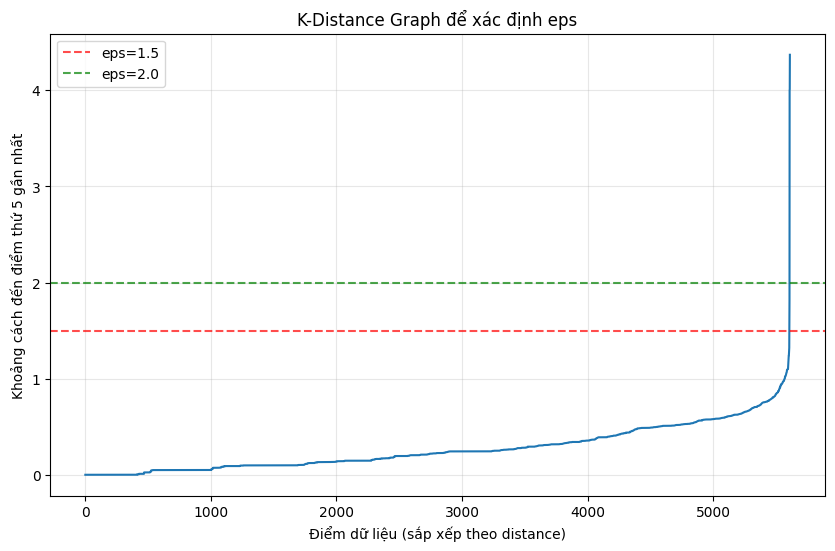

In [73]:
from sklearn.neighbors import NearestNeighbors

# Phân cụm DBSCAN mật độ (PHÁT HIỆN OUTLIERS) 
# Tìm eps tối ưu: Dựa trên k-distance (k=min_samples-1=4)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Lấy distance của điểm thứ 5 gần nhất
k_dist = np.sort(distances[:, 4])  # 4th nearest distance

# Vẽ k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_dist)
plt.xlabel('Điểm dữ liệu (sắp xếp theo distance)')
plt.ylabel('Khoảng cách đến điểm thứ 5 gần nhất')
plt.title('K-Distance Graph để xác định eps')
plt.grid(True, alpha=0.3)
plt.axhline(y=1.5, color='r', linestyle='--', alpha=0.7, label='eps=1.5')
plt.axhline(y=2.0, color='g', linestyle='--', alpha=0.7, label='eps=2.0')
plt.legend()
plt.show()  # Chạy để xem elbow ~0.8-1.2


In [74]:
# # Tune: Thử eps=1.0 (dựa trên graph est.)
# eps_candidates = [0.8, 1.0, 1.2]
# best_eps, best_noise = None, float('inf')
# for eps in eps_candidates:
#     dbscan_tune = DBSCAN(eps=eps, min_samples=5)
#     labels_tune = dbscan_tune.fit_predict(X_scaled)
#     n_noise_tune = list(labels_tune).count(-1)
#     if n_noise_tune < best_noise:
#         best_noise = n_noise_tune
#         best_eps = eps
#         best_labels = labels_tune
# print(f"Best eps: {best_eps}, Noise: {best_noise}")

# Chạy DBSCAN với eps=1.5
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)


# DBSCAN
# Thêm kết quả DBSCAN vào dataframe
df.loc[X_cluster.index, 'dbscan_cluster'] = dbscan_labels
# Phân tích kết quả DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
# print(f"DBSCAN: {n_clusters_db} cụm, {best_noise} outliers")

print(f"DBSCAN tìm thấy: {n_clusters_db} cụm")
print(f"Số lượng outliers (nhiễu): {n_noise} ({n_noise/len(X_cluster)*100:.1f}%)")

DBSCAN tìm thấy: 1 cụm
Số lượng outliers (nhiễu): 4 (0.1%)


In [75]:
if n_clusters_db > 0:
    print("\nPhân tích các cụm DBSCAN:")
    for i in range(n_clusters_db):
        cluster_mask = dbscan_labels == i
        size = sum(cluster_mask)
        print(f"  Cụm {i}: {size} điểm ({size/len(X_cluster)*100:.1f}%)")


Phân tích các cụm DBSCAN:
  Cụm 0: 5608 điểm (99.9%)


In [76]:
# cluster_summary = df.loc[X_cluster.index].groupby('kmeans_cluster')[features_cluster + ['area_type']].agg({
#     'price_million': 'mean', 'area_m2': 'mean', 'amenities_count': 'mean',
#     'district_encoded': lambda x: le_district.inverse_transform([x.mode()[0]])[0],
#     'area_type': lambda x: x.mode().iloc[0]
# }).round(2)
# print(cluster_summary)

### Trực quan hóa kết quả phân cụm

In [77]:
# # Viz: Scatter price-area color by cluster

# plt.scatter(df.loc[X_cluster.index, 'area_m2'], df.loc[X_cluster.index, 'price_million'], 
#             c=df.loc[X_cluster.index, 'kmeans_cluster'], cmap='viridis', alpha=0.6)
# plt.xlabel('Diện tích (m²)'); plt.ylabel('Giá (triệu)'); plt.title('Phân cụm K-Means'); plt.colorbar(label='Cluster'); plt.show()

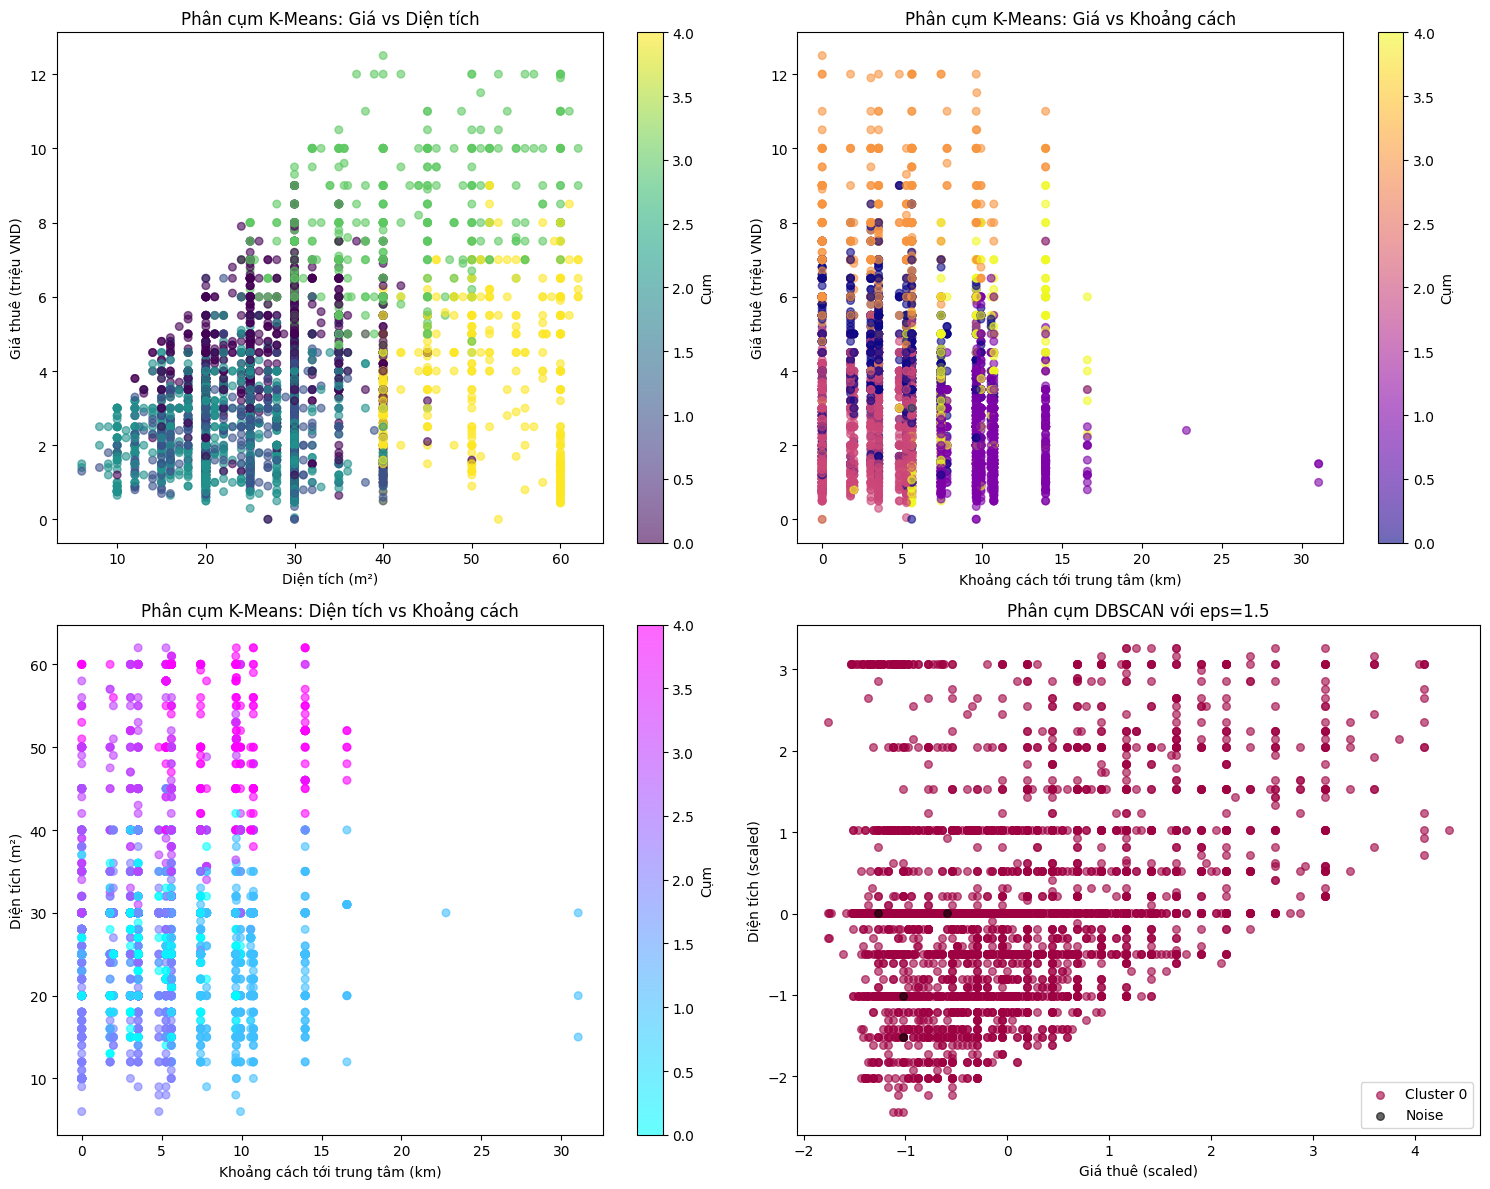

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Phân cụm K-Means theo giá và diện tích
scatter1 = axes[0, 0].scatter(X_cluster['area_m2'], X_cluster['price_million'], 
                             c=kmeans_labels, cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_xlabel('Diện tích (m²)')
axes[0, 0].set_ylabel('Giá thuê (triệu VND)')
axes[0, 0].set_title('Phân cụm K-Means: Giá vs Diện tích')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cụm')

# 2. Phân cụm K-Means theo giá và khoảng cách
scatter2 = axes[0, 1].scatter(X_cluster['distance_to_center_km'], X_cluster['price_million'], 
                             c=kmeans_labels, cmap='plasma', alpha=0.6, s=30)
axes[0, 1].set_xlabel('Khoảng cách tới trung tâm (km)')
axes[0, 1].set_ylabel('Giá thuê (triệu VND)')
axes[0, 1].set_title('Phân cụm K-Means: Giá vs Khoảng cách')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cụm')

# 3. Phân cụm K-Means theo diện tích và khoảng cách
scatter3 = axes[1, 0].scatter(X_cluster['distance_to_center_km'], X_cluster['area_m2'], 
                             c=kmeans_labels, cmap='cool', alpha=0.6, s=30)
axes[1, 0].set_xlabel('Khoảng cách tới trung tâm (km)')
axes[1, 0].set_ylabel('Diện tích (m²)')
axes[1, 0].set_title('Phân cụm K-Means: Diện tích vs Khoảng cách')
plt.colorbar(scatter3, ax=axes[1, 0], label='Cụm')

# 4. Phân cụm DBSCAN
unique_labels = set(dbscan_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black for noise
        col = [0, 0, 0, 1]
        label = 'Noise'
    else:
        label = f'Cluster {k}'
    
    class_member_mask = (dbscan_labels == k)
    xy = X_scaled[class_member_mask]
    axes[1, 1].scatter(xy[:, 0], xy[:, 1], c=[col], alpha=0.6, s=30, label=label)

axes[1, 1].set_xlabel('Giá thuê (scaled)')
axes[1, 1].set_ylabel('Diện tích (scaled)')
axes[1, 1].set_title('Phân cụm DBSCAN với eps=1.5')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Phân tích giá trị tốt nhất (Best Value)

In [79]:
# Tính điểm giá trị cho từng cụm
df_clustered['value_score'] = (
    (df_clustered['area_m2'] / df_clustered['area_m2'].max()) * 0.4 +
    (1 - df_clustered['price_million'] / df_clustered['price_million'].max()) * 0.4 +
    (1 - df_clustered['distance_to_center_km'] / df_clustered['distance_to_center_km'].max()) * 0.2
)

# Tính điểm giá trị trung bình cho từng cụm
cluster_value_scores = df_clustered.groupby('kmeans_cluster').agg({
    'value_score': 'mean',
    'price_million': 'mean',
    'area_m2': 'mean',
    'distance_to_center_km': 'mean',
    'amenities_count': 'mean'
}).round(3).sort_values('value_score', ascending=False)

print("\nXẾP HẠNG CÁC CỤM THEO GIÁ TRỊ (Value for Money):")
print("Giá trị cao nhất = tốt nhất cho người thuê")
display(cluster_value_scores)

# Xác định cụm tốt nhất
best_cluster = cluster_value_scores.index[0]
print(f"\nCụm mang lại giá trị tốt nhất cho người thuê: CỤM {best_cluster}")
print(f"Lý do: Có điểm giá trị cao nhất ({cluster_value_scores.iloc[0]['value_score']:.3f})")

# Phân tích chi tiết cụm tốt nhất
print("\nĐẶC ĐIỂM CỤM TỐT NHẤT:")
best_cluster_data = df_clustered[df_clustered['kmeans_cluster'] == best_cluster]
print(f"- Giá thuê trung bình: {best_cluster_data['price_million'].mean():.2f} triệu")
print(f"- Diện tích trung bình: {best_cluster_data['area_m2'].mean():.1f} m²")
print(f"- Giá/m² trung bình: {(best_cluster_data['price_million'] / best_cluster_data['area_m2']).mean():.3f} triệu/m²")
print(f"- Khoảng cách TB tới trung tâm: {best_cluster_data['distance_to_center_km'].mean():.1f} km")

# Top 5 quận trong cụm tốt nhất
top_districts = best_cluster_data['district_extracted'].value_counts().head(5)
print("\nTop 5 quận trong cụm tốt nhất:")
for district, count in top_districts.items():
    percentage = count / len(best_cluster_data) * 100
    avg_price = best_cluster_data[best_cluster_data['district_extracted'] == district]['price_million'].mean()
    print(f"  {district}: {count} tin ({percentage:.1f}%) - Giá TB: {avg_price:.1f} triệu")


XẾP HẠNG CÁC CỤM THEO GIÁ TRỊ (Value for Money):
Giá trị cao nhất = tốt nhất cho người thuê


,value_score,price_million,area_m2,distance_to_center_km,amenities_count
kmeans_cluster,,,,,
4,0.755,3.530,49.279,7.739,1.733
2,0.660,2.635,25.463,3.131,1.509
1,0.629,2.370,26.393,10.137,1.755
0,0.617,4.282,28.211,4.376,4.549
3,0.585,7.411,38.234,3.768,1.850



Cụm mang lại giá trị tốt nhất cho người thuê: CỤM 4
Lý do: Có điểm giá trị cao nhất (0.755)

ĐẶC ĐIỂM CỤM TỐT NHẤT:
- Giá thuê trung bình: 3.53 triệu
- Diện tích trung bình: 49.3 m²
- Giá/m² trung bình: 0.073 triệu/m²
- Khoảng cách TB tới trung tâm: 7.7 km

Top 5 quận trong cụm tốt nhất:
  Gò Vấp: 169 tin (32.7%) - Giá TB: 3.1 triệu
  Tân Bình: 109 tin (21.1%) - Giá TB: 1.9 triệu
  Quận 9: 40 tin (7.7%) - Giá TB: 5.9 triệu
  Quận 7: 29 tin (5.6%) - Giá TB: 4.4 triệu
  Tân Phú: 29 tin (5.6%) - Giá TB: 5.3 triệu


## 5.2. Thực nghiệm 2: Đánh giá Các yếu tố Ảnh hưởng đến Giá thuê (Trả lời câu 2)
### Mục tiêu
Xác định yếu tố ảnh hưởng mạnh nhất đến giá: diện tích (**area_m2**) hay vị trí (**district_encoded**)? Bao gồm tiện nghi, đặc trưng địa lý (hẻm, hướng đường).

### Phương pháp
- **Hồi quy tuyến tính**: Đánh giá hệ số hồi quy (coefficient) cho mối quan hệ tuyến tính.
- **Random Forest Regressor**: Feature importance (phi tuyến).
- **Features**: **area_m2**, **district_encoded**, **amenities_count**, **road_width_category_encoded** (LabelEncoder cho độ rộng đường), **alley_type_encoded** (loại hẻm), **street_direction_encoded**.
- **Đánh giá**: R² score, MAE.

### Tiền xử lý

In [80]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mã hóa các biến categorical
categorical_features = ['district_extracted', 'area_type', 'size_category', 'street_type', 'alley_type']
label_encoders = {}

for feature in categorical_features:
    le = LabelEncoder()
    df[f'{feature}_encoded'] = le.fit_transform(df[feature].fillna('Không xác định'))
    label_encoders[feature] = le
    print(f"Đã mã hóa {feature}: {len(le.classes_)} giá trị")

# Chọn features cho hồi quy
features_reg = [
    'area_m2',                    # Diện tích
    'district_extracted_encoded', # Vị trí quận (mã hóa)
    'distance_to_center_km',      # Khoảng cách tới trung tâm
    'amenities_count',            # Số tiện nghi
    'has_wifi', 'has_parking', 'has_aircon', 'has_water_heater',
    'has_security', 'has_elevator', 'has_interior', 'has_washing',
    'area_type_encoded',          # Loại khu vực
    'size_category_encoded',      # Loại diện tích
    'street_type_encoded',        # Loại đường
    'alley_type_encoded',         # Loại hẻm
    'year'                        # Năm đăng tin
]

# Chuẩn bị X và y
X_reg = df[features_reg].copy()
y_reg = df['price_million']

# Loại bỏ missing values
X_reg = X_reg.dropna()
y_reg = y_reg.loc[X_reg.index]

print(f"\nKích thước dữ liệu cho hồi quy: {X_reg.shape}")

# Chia dữ liệu train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Đã mã hóa district_extracted: 21 giá trị
Đã mã hóa area_type: 4 giá trị
Đã mã hóa size_category: 4 giá trị
Đã mã hóa street_type: 3 giá trị
Đã mã hóa alley_type: 2 giá trị

Kích thước dữ liệu cho hồi quy: (5612, 17)
Train set: (4489, 17)
Test set: (1123, 17)


### Hồi quy tuyến tính & Random Forest

In [81]:
# Hồi quy tuyến tính
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán
y_pred_lr = lr_model.predict(X_test)

# Đánh giá
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr:.3f} triệu")
print(f"RMSE: {rmse_lr:.3f} triệu")
print(f"R² Score: {r2_lr:.3f}")

# Cross-validation
cv_scores = cross_val_score(lr_model, X_reg, y_reg, cv=5, scoring='r2')
print(f"Cross-validation R²: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

# Phân tích hệ số hồi quy
coeff_df = pd.DataFrame({
    'Feature': features_reg,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTOP 10 YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT (Linear Regression):")
display(coeff_df.head(10))


MAE: 1.330 triệu
RMSE: 1.753 triệu
R² Score: 0.256
Cross-validation R²: 0.262 (±0.015)

TOP 10 YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT (Linear Regression):


,Feature,Coefficient,Abs_Coefficient
10,has_interior,1.100039,1.100039
4,has_wifi,-0.613973,0.613973
5,has_parking,-0.481488,0.481488
9,has_elevator,0.451210,0.451210
12,area_type_encoded,0.226222,0.226222
3,amenities_count,0.198854,0.198854
11,has_washing,-0.155329,0.155329
8,has_security,-0.146716,0.146716
13,size_category_encoded,-0.136184,0.136184
15,alley_type_encoded,0.080229,0.080229


In [82]:
# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)

# Đánh giá
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.3f} triệu")
print(f"RMSE: {rmse_rf:.3f} triệu")
print(f"R² Score: {r2_rf:.3f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_reg, y_reg, cv=5, scoring='r2')
print(f"Cross-validation R²: {cv_scores_rf.mean():.3f} (±{cv_scores_rf.std():.3f})")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features_reg,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 10 YẾU TỐ QUAN TRỌNG NHẤT (Random Forest):")
display(importance_df.head(10))

MAE: 1.168 triệu
RMSE: 1.564 triệu
R² Score: 0.408
Cross-validation R²: 0.405 (±0.017)

TOP 10 YẾU TỐ QUAN TRỌNG NHẤT (Random Forest):


,Feature,Importance
0,area_m2,0.314587
10,has_interior,0.193811
2,distance_to_center_km,0.121342
1,district_extracted_encoded,0.082383
3,amenities_count,0.062693
12,area_type_encoded,0.036576
16,year,0.035878
6,has_aircon,0.034431
4,has_wifi,0.023497
9,has_elevator,0.019806


In [83]:
# SO SÁNH: DIỆN TÍCH vs VỊ TRÍ QUẬN
# Tạo mô hình chỉ với diện tích
lr_area = LinearRegression()
lr_area.fit(X_train[['area_m2']], y_train)
r2_area = r2_score(y_test, lr_area.predict(X_test[['area_m2']]))

# Tạo mô hình chỉ với vị trí quận
lr_district = LinearRegression()
lr_district.fit(X_train[['district_extracted_encoded']], y_train)
r2_district = r2_score(y_test, lr_district.predict(X_test[['district_extracted_encoded']]))

# Tạo mô hình với cả hai
lr_both = LinearRegression()
lr_both.fit(X_train[['area_m2', 'district_extracted_encoded']], y_train)
r2_both = r2_score(y_test, lr_both.predict(X_test[['area_m2', 'district_extracted_encoded']]))

print("KẾT QUẢ SO SÁNH:")
print(f"Chỉ với Diện tích: R² = {r2_area:.3f}")
print(f"Chỉ với Vị trí quận: R² = {r2_district:.3f}")
print(f"Cả Diện tích và Vị trí: R² = {r2_both:.3f}")

# Phân tích từ Random Forest
area_importance = importance_df[importance_df['Feature'] == 'area_m2']['Importance'].values[0]
district_importance = importance_df[importance_df['Feature'] == 'district_extracted_encoded']['Importance'].values[0]

print("\nTHEO RANDOM FOREST:")
print(f"Importance của Diện tích: {area_importance:.3f}")
print(f"Importance của Vị trí quận: {district_importance:.3f}")

if area_importance > district_importance:
    print("KẾT LUẬN: Diện tích ảnh hưởng mạnh hơn đến giá thuê")
else:
    print("KẾT LUẬN: Vị trí quận ảnh hưởng mạnh hơn đến giá thuê")


KẾT QUẢ SO SÁNH:
Chỉ với Diện tích: R² = 0.089
Chỉ với Vị trí quận: R² = -0.001
Cả Diện tích và Vị trí: R² = 0.091

THEO RANDOM FOREST:
Importance của Diện tích: 0.315
Importance của Vị trí quận: 0.082
KẾT LUẬN: Diện tích ảnh hưởng mạnh hơn đến giá thuê


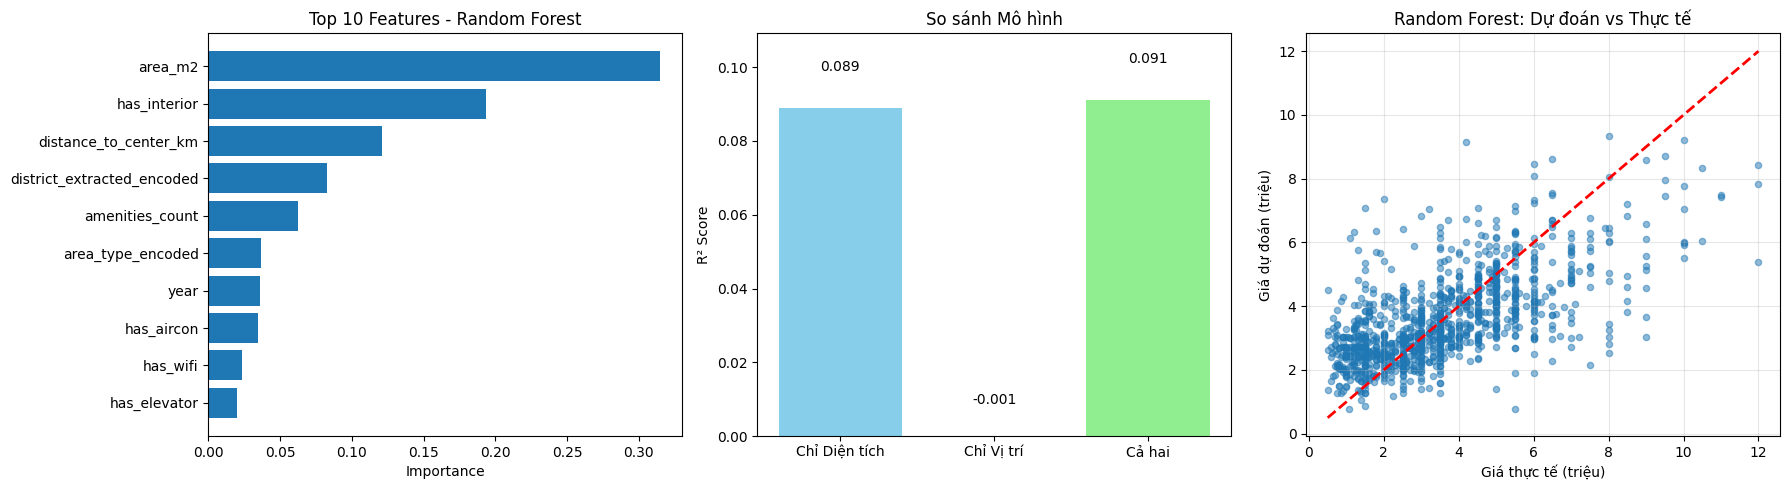

In [84]:
# TRỰC QUAN HÓA KẾT QUẢ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature Importance từ Random Forest
top_features = importance_df.head(10)
axes[0].barh(range(len(top_features)), top_features['Importance'])
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Features - Random Forest')
axes[0].invert_yaxis()

# 2. So sánh R² scores
models = ['Chỉ Diện tích', 'Chỉ Vị trí', 'Cả hai']
r2_scores = [r2_area, r2_district, r2_both]
axes[1].bar(models, r2_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_ylabel('R² Score')
axes[1].set_title('So sánh Mô hình')
axes[1].set_ylim(0, max(r2_scores) * 1.2)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# 3. So sánh dự đoán vs thực tế
axes[2].scatter(y_test, y_pred_rf, alpha=0.5, s=20)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Giá thực tế (triệu)')
axes[2].set_ylabel('Giá dự đoán (triệu)')
axes[2].set_title('Random Forest: Dự đoán vs Thực tế')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [85]:
# PHÂN TÍCH TƯƠNG QUAN CHI TIẾT
# Tính tương quan
correlation_with_price = pd.DataFrame({
    'Feature': features_reg,
    'Correlation': [df['price_million'].corr(df[feat]) if df[feat].dtype != 'object' else np.nan 
                    for feat in features_reg]
})

correlation_with_price = correlation_with_price.dropna().sort_values('Correlation', key=abs, ascending=False)

print("TƯƠNG QUAN VỚI GIÁ THUÊ:")
display(correlation_with_price.head(10))

TƯƠNG QUAN VỚI GIÁ THUÊ:


,Feature,Correlation
10,has_interior,0.359511
0,area_m2,0.310273
3,amenities_count,0.179050
6,has_aircon,0.165659
12,area_type_encoded,0.162018
9,has_elevator,0.155101
2,distance_to_center_km,-0.143168
11,has_washing,0.107990
4,has_wifi,-0.090405
7,has_water_heater,0.063739


## 5.3. Thực nghiệm 3: Dự đoán Phân khúc Giá (Trả lời câu hỏi 3)
### Mục tiêu
Phân loại phòng trọ thành 3 nhóm giá: Thấp (<2.5M), Trung bình (2.5-4M), Cao (>4M) dựa trên đặc tính cơ bản.

### Biến đầu vào
area_m2, district_encoded, amenities_count, description_length (độ dài mô tả), alley_type_encoded, kmeans_cluster_encoded.

### Thuật toán sử dụng
- Baseline: Logistic Regression.
- Decision Tree, Random Forest, XGBoost.
- Đánh giá: Accuracy, F1-score (macro), Confusion Matrix.

In [86]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Tạo target variable: phân loại giá thành 3 nhóm
df['price_category'] = pd.cut(
    df['price_million'],
    bins=[0, 2.5, 4, 100],
    labels=['Thấp (<2.5M)', 'Trung bình (2.5-4M)', 'Cao (>4M)']
)

print("Phân bố các nhóm giá:")
category_dist = df['price_category'].value_counts().sort_index()
for category, count in category_dist.items():
    percentage = count / len(df) * 100
    print(f"  {category}: {count} ({percentage:.1f}%)")

# Mã hóa target
le_target = LabelEncoder()
df['price_category_encoded'] = le_target.fit_transform(df['price_category'])

print("\nMapping target categories:")
for i, cat in enumerate(le_target.classes_):
    print(f"  {i}: {cat}")

# Chọn features cho phân loại
features_class = [
    'area_m2',
    'district_extracted_encoded',
    'distance_to_center_km',
    'amenities_count',
    'has_wifi', 'has_parking', 'has_aircon',
    'has_security', 'has_elevator',
    'area_type_encoded',
    'size_category_encoded',
    'year',
    'kmeans_cluster'  # Thêm kết quả từ phân cụm
]

# Điền NaN trong kmeans_cluster
df['kmeans_cluster'] = df['kmeans_cluster'].fillna(-1)

# Chuẩn bị X và y
X_class = df[features_class].copy()
y_class = df['price_category_encoded']

# Loại bỏ missing values
X_class = X_class.dropna()
y_class = y_class.loc[X_class.index]

print(f"\nKích thước dữ liệu cho phân loại: {X_class.shape}")

# Scale features (trừ các biến đã là encoded)
scaler_class = StandardScaler()
X_scaled_class = scaler_class.fit_transform(X_class)

# Chia dữ liệu train-test (stratified để giữ phân bố các lớp)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled_class, y_class, test_size=0.2, random_state=42, 
    stratify=y_class, shuffle=True
)

print(f"Train set: {X_train_c.shape}")
print(f"Test set: {X_test_c.shape}")

Phân bố các nhóm giá:
  Thấp (<2.5M): 2004 (35.7%)
  Trung bình (2.5-4M): 1692 (30.1%)
  Cao (>4M): 1916 (34.1%)

Mapping target categories:
  0: Cao (>4M)
  1: Thấp (<2.5M)
  2: Trung bình (2.5-4M)

Kích thước dữ liệu cho phân loại: (5612, 13)
Train set: (4489, 13)
Test set: (1123, 13)


### Xây dựng và đánh giá các mô hình phân loại

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Danh sách các mô hình sẽ thử nghiệm
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                           random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                                   max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                            random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

# Lưu kết quả
results = []

# Huấn luyện và đánh giá từng mô hình
for name, model in models.items():
    print(f"\n{'-'*50}")
    print(f"Đang huấn luyện: {name}")
    print('-'*50)
    
    # Huấn luyện mô hình
    model.fit(X_train_c, y_train_c)
    
    # Dự đoán
    y_pred = model.predict(X_test_c)
    y_pred_proba = model.predict_proba(X_test_c) if hasattr(model, "predict_proba") else None
    
    # Tính các metrics
    accuracy = accuracy_score(y_test_c, y_pred)
    precision = precision_score(y_test_c, y_pred, average='weighted')
    recall = recall_score(y_test_c, y_pred, average='weighted')
    f1 = f1_score(y_test_c, y_pred, average='weighted')
    
    # AUC-ROC (nếu có probability)
    auc = roc_auc_score(y_test_c, y_pred_proba, multi_class='ovr') if y_pred_proba is not None else np.nan
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled_class, y_class, cv=5, scoring='accuracy')
    
    # Lưu kết quả
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std()
    })
    
    # In kết quả chi tiết
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    if not np.isnan(auc):
        print(f"AUC-ROC: {auc:.3f}")
    print(f"Cross-validation Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # In classification report
    print("\nClassification Report:")
    print(classification_report(y_test_c, y_pred, 
                                target_names=le_target.classes_))

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results).round(3)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH")
print("-" * 80)
display(results_df)


--------------------------------------------------
Đang huấn luyện: Logistic Regression
--------------------------------------------------
Accuracy: 0.563
Precision: 0.556
Recall: 0.563
F1-Score: 0.556
AUC-ROC: 0.745
Cross-validation Accuracy: 0.550 (±0.015)

Classification Report:
                     precision    recall  f1-score   support

          Cao (>4M)       0.61      0.63      0.62       383
       Thấp (<2.5M)       0.57      0.66      0.62       401
Trung bình (2.5-4M)       0.48      0.37      0.42       339

           accuracy                           0.56      1123
          macro avg       0.55      0.55      0.55      1123
       weighted avg       0.56      0.56      0.56      1123


--------------------------------------------------
Đang huấn luyện: Decision Tree
--------------------------------------------------
Accuracy: 0.615
Precision: 0.620
Recall: 0.615
F1-Score: 0.613
AUC-ROC: 0.781
Cross-validation Accuracy: 0.609 (±0.009)

Classification Report:
        

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV Accuracy Mean,CV Accuracy Std
3,Gradient Boosting,0.693,0.689,0.693,0.689,0.850,0.660,0.014
2,Random Forest,0.687,0.683,0.687,0.684,0.849,0.651,0.009
4,XGBoost,0.687,0.682,0.687,0.681,0.852,0.666,0.018
1,Decision Tree,0.615,0.620,0.615,0.613,0.781,0.609,0.009
0,Logistic Regression,0.563,0.556,0.563,0.556,0.745,0.550,0.015



MÔ HÌNH TỐT NHẤT: Gradient Boosting
F1-Score: 0.689
Accuracy: 0.693

CONFUSION MATRIX (Mô hình tốt nhất):
[[293  36  54]
 [ 21 313  67]
 [ 65 102 172]]

TOP 10 FEATURES QUAN TRỌNG NHẤT:


,Feature,Importance
12,kmeans_cluster,0.449711
0,area_m2,0.142507
2,distance_to_center_km,0.076245
1,district_extracted_encoded,0.071956
3,amenities_count,0.069092
9,area_type_encoded,0.044361
11,year,0.031635
5,has_parking,0.028129
4,has_wifi,0.027392
6,has_aircon,0.018238


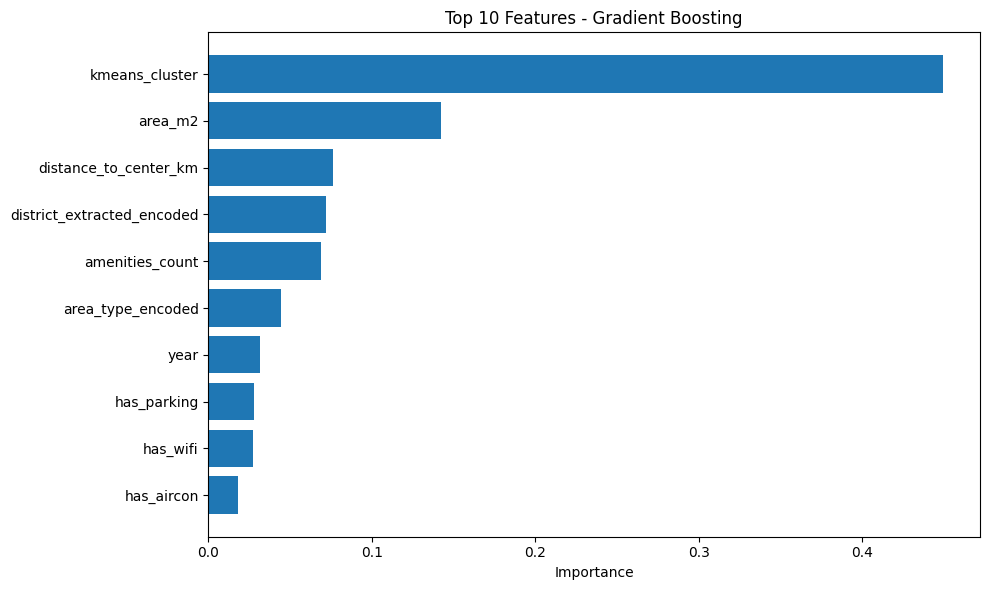

In [88]:
# PHÂN TÍCH MÔ HÌNH TỐT NHẤT 
best_model_name = results_df.iloc[0]['Model']
print(f"\nMÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score']:.3f}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.3f}")

# Lấy mô hình tốt nhất
best_model = models[best_model_name]

# Confusion Matrix cho mô hình tốt nhất
y_pred_best = best_model.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_best)

print("\nCONFUSION MATRIX (Mô hình tốt nhất):")
print(cm)

# Feature importance (nếu mô hình có)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': features_class,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTOP 10 FEATURES QUAN TRỌNG NHẤT:")
    display(feature_importance.head(10))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


### Trực quan hóa kết quả

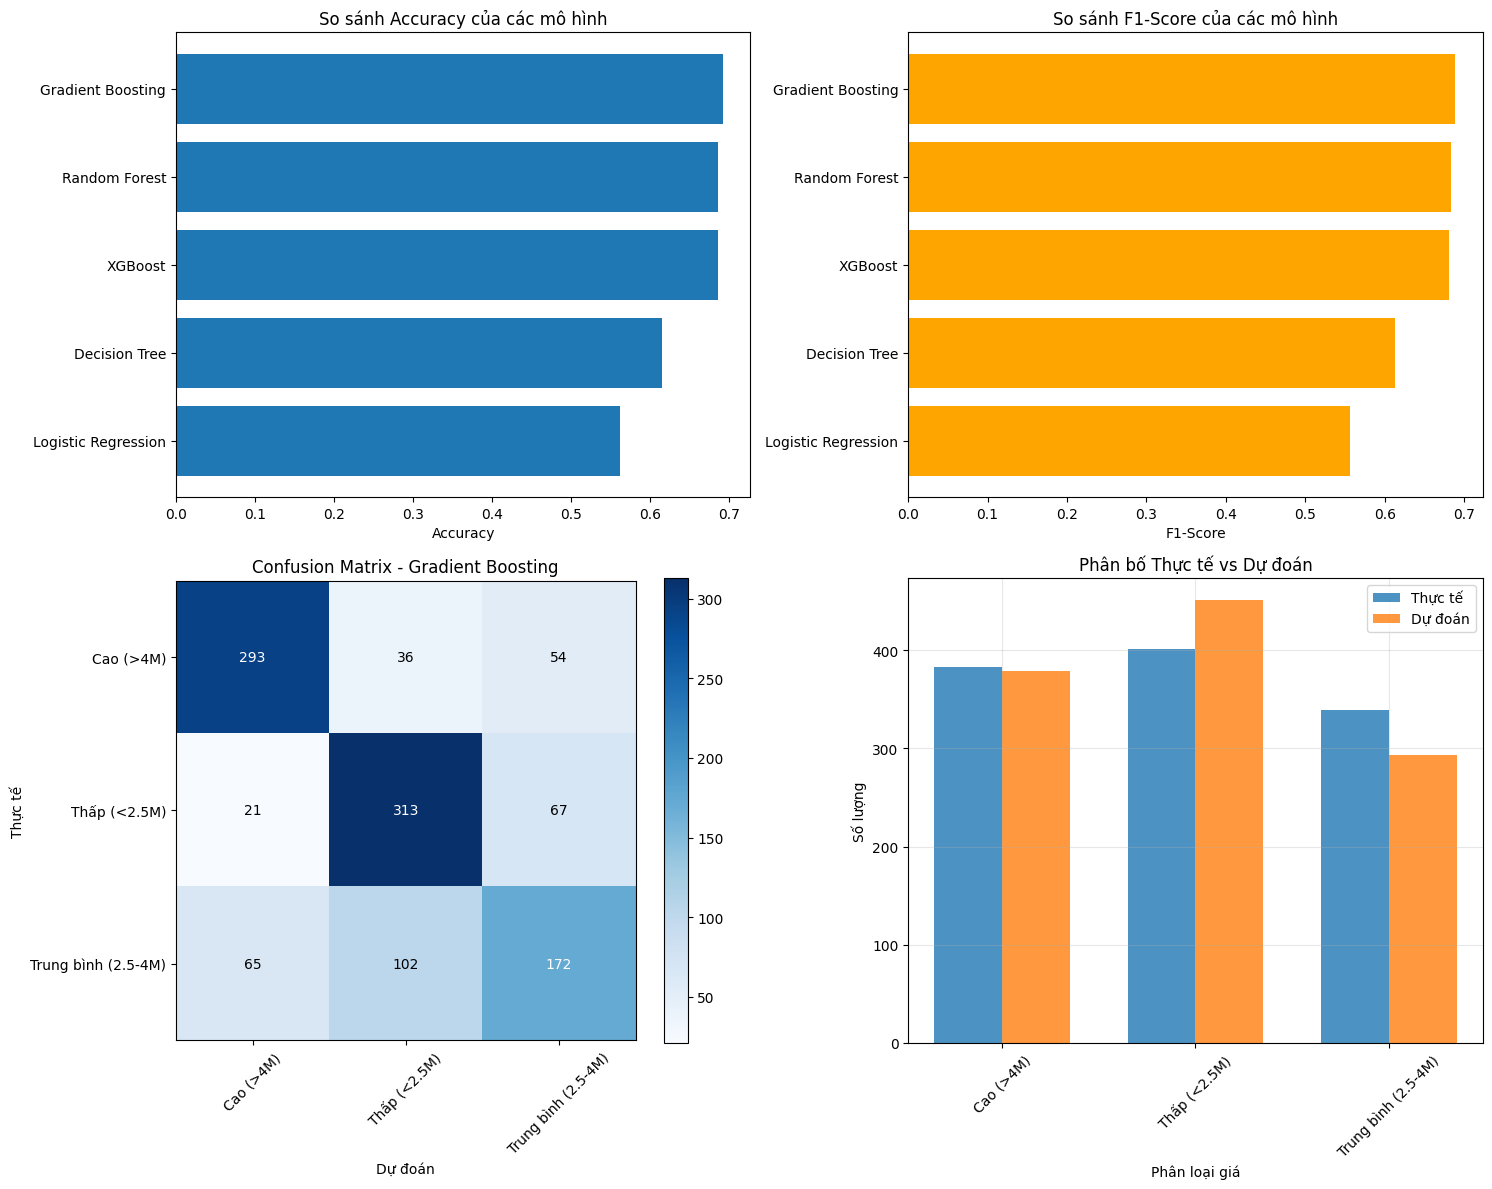

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. So sánh accuracy của các mô hình
axes[0, 0].barh(range(len(results_df)), results_df['Accuracy'])
axes[0, 0].set_yticks(range(len(results_df)))
axes[0, 0].set_yticklabels(results_df['Model'])
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('So sánh Accuracy của các mô hình')
axes[0, 0].invert_yaxis()

# 2. So sánh F1-Score
axes[0, 1].barh(range(len(results_df)), results_df['F1-Score'], color='orange')
axes[0, 1].set_yticks(range(len(results_df)))
axes[0, 1].set_yticklabels(results_df['Model'])
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('So sánh F1-Score của các mô hình')
axes[0, 1].invert_yaxis()

# 3. Confusion Matrix heatmap
im = axes[1, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}')
plt.colorbar(im, ax=axes[1, 0])

# Thêm số vào các ô
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1, 0].text(j, i, format(cm[i, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i, j] > thresh else "black")

axes[1, 0].set_xticks(range(len(le_target.classes_)))
axes[1, 0].set_yticks(range(len(le_target.classes_)))
axes[1, 0].set_xticklabels(le_target.classes_, rotation=45)
axes[1, 0].set_yticklabels(le_target.classes_)
axes[1, 0].set_ylabel('Thực tế')
axes[1, 0].set_xlabel('Dự đoán')

# 4. Phân bố dự đoán vs thực tế
unique_classes = np.unique(y_test_c)
x_pos = np.arange(len(unique_classes))
width = 0.35

actual_counts = [sum(y_test_c == c) for c in unique_classes]
predicted_counts = [sum(y_pred_best == c) for c in unique_classes]

axes[1, 1].bar(x_pos - width/2, actual_counts, width, label='Thực tế', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, predicted_counts, width, label='Dự đoán', alpha=0.8)
axes[1, 1].set_xlabel('Phân loại giá')
axes[1, 1].set_ylabel('Số lượng')
axes[1, 1].set_title('Phân bố Thực tế vs Dự đoán')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(le_target.classes_, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Kết quả và đánh giá

In [90]:
print("1. KẾT QUẢ TỔNG QUAN:")
print(f" - Mô hình tốt nhất: {best_model_name}")
print(f" - Độ chính xác: {results_df.iloc[0]['Accuracy']:.3f}")
print(f" - F1-Score: {results_df.iloc[0]['F1-Score']:.3f}")

print("\n2. KHẢ NĂNG DỰ ĐOÁN PHÂN KHÚC GIÁ:")
accuracy_threshold = 0.7  # Ngưỡng chấp nhận được
if results_df.iloc[0]['Accuracy'] > accuracy_threshold:
    print(f" CÓ THỂ dự đoán chính xác phân khúc giá")
    print(f" Độ chính xác đạt {results_df.iloc[0]['Accuracy']*100:.1f}% (> {accuracy_threshold*100}%)")
else:
    print(f" KHÔNG THỂ dự đoán chính xác phân khúc giá")
    print(f" Độ chính xác chỉ đạt {results_df.iloc[0]['Accuracy']*100:.1f}% (< {accuracy_threshold*100}%)")

print("\n3. YẾU TỐ QUAN TRỌNG NHẤT ĐỂ DỰ ĐOÁN:")
if 'feature_importance' in locals():
    top_3_features = feature_importance.head(3)
    for i, (_, row) in enumerate(top_3_features.iterrows(), 1):
        print(f"   {i}. {row['Feature']}: {row['Importance']:.3f}")


1. KẾT QUẢ TỔNG QUAN:
 - Mô hình tốt nhất: Gradient Boosting
 - Độ chính xác: 0.693
 - F1-Score: 0.689

2. KHẢ NĂNG DỰ ĐOÁN PHÂN KHÚC GIÁ:
 KHÔNG THỂ dự đoán chính xác phân khúc giá
 Độ chính xác chỉ đạt 69.3% (< 70.0%)

3. YẾU TỐ QUAN TRỌNG NHẤT ĐỂ DỰ ĐOÁN:
   1. kmeans_cluster: 0.450
   2. area_m2: 0.143
   3. distance_to_center_km: 0.076


# KẾT THÚC